# مشروع السلاسل الزمنية
# متطلبات المشروع
### 1- Dataset
### 2- Visualization
### 3- Feature Engineering
### 4- Statistics
### 5- ACF / PACF
### 6- Moving Average
### 7- Power Transform
### 8- ADF Test
### 9- معالجة السلسلة
### 10- ARMA
### 11- ARIMA
### 12- SARIMA
### 13- Machine Learning
### 14- Deep Learning
### 15- Evaluation


# بناء وتقييم نماذج ARMA / ARIMA / SARIMA للسلاسل الزمنية

في هذا النوت بوك سنبني مسارًا متكاملًا لتحليل سلسلة زمنية ثم نمذجتها باستخدام:

- **ARMA**
- **ARIMA**
- **SARIMA**

وسنمر بالمراحل التالية:

1. استكشاف السلسلة الزمنية
2. استكشاف توزيع القيم
3. فحص الثبات (Stationarity)
4. تفكيك السلسلة الزمنية
5. معالجة السلسلة عند الحاجة
6. تقسيم البيانات إلى تدريب واختبار
7. بناء النماذج ومقارنتها
8. تحليل بواقي الأخطاء
9. اختيار أفضل نموذج
10. حفظ النموذج لاستخدامه لاحقًا في التنبؤ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## استيراد المكتبات

سنستخدم في هذا النوت بوك مكتبات التحليل الإحصائي والرسم والنمذجة الخاصة بالسلاسل الزمنية.

In [ ]:
!pip install statsmodels

In [ ]:
import warnings
import itertools
import pickle

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import lag_plot
from pandas import DataFrame, Grouper, concat
from scipy.stats import boxcox # عشان نستخدم boxcox احدى طرق Power Transform

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## تحميل البيانات وتجهيز السلسلة الزمنية

في هذه الخطوة نقرأ البيانات ونحدد العمود الزمني والعمود المستهدف الذي نريد التنبؤ به.

> **مهم:** يجب أن تكون السلسلة الزمنية:
- مرتبة زمنيًا
- مفهرسة بتاريخ/وقت
- تحتوي على عمود رقمي يمثل القيم المراد التنبؤ بها

In [ ]:
# قراءة الملف
df = pd.read_csv('/content/saudi-oil-database.csv')

df[['Time Period',
    'Energy Product Name',
    'Flow breakdown',
    'Unit of Measure',
    'Value',
    'Assessment Code']] = df['Time Period;Energy Product Name;Flow breakdown;Unit of Measure;Value;Assessment Code'].str.split(';', expand=True)

df.drop('Time Period;Energy Product Name;Flow breakdown;Unit of Measure;Value;Assessment Code', axis=1, inplace=True)

df.dropna()

df["Value"] = df["Value"].str.replace(",", "")
df["Value"] = pd.to_numeric(df["Value"])

df = df.sort_values(by = 'Value')

df = df[df['Value'] > 0]


df.drop('Assessment Code', axis= 1, inplace= True)

df['Energy Product Name'].value_counts()

df = df.rename(columns={'Time Period': 'DATE'})


# تحويل عمود التاريخ إلى datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# ترتيب البيانات زمنيًا
df = df.sort_values('DATE')

# جعل التاريخ هو الفهرس
df = df.set_index('DATE')

oil_df = df[df['Energy Product Name'] == 'Crude Oil']

# استخراج السلسلة الزمنية من العمود المستهدف
series = oil_df['Value'].copy()

# لأن البيانات شهرية نضبط التردد الشهري
series = series.asfreq('MS')

# حذف القيم المفقودة إن وجدت
series = series.dropna()

print("Number of observations:", len(series))
print(series.head())
print(series.tail())

Number of observations: 284
DATE
2002-01-01    28024.1025
2002-02-01    24172.4697
2002-03-01    27141.8805
2002-04-01    26404.6552
2002-05-01    27225.6670
Freq: MS, Name: Value, dtype: float64
DATE
2025-04-01    29409.5202
2025-05-01    30513.0529
2025-06-01    29290.2795
2025-07-01    29542.1158
2025-08-01    31577.6336
Freq: MS, Name: Value, dtype: float64


In [ ]:
oil_df

,Energy Product Name,Flow breakdown,Unit of Measure,Value
DATE,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025
2002-02-01,Crude Oil,Exports,KL,24172.4697
2002-03-01,Crude Oil,Exports,KL,27141.8805
2002-04-01,Crude Oil,Exports,KL,26404.6552
2002-05-01,Crude Oil,Exports,KL,27225.6670
...,...,...,...,...
2025-04-01,Crude Oil,Exports,KL,29409.5202
2025-05-01,Crude Oil,Exports,KL,30513.0529
2025-06-01,Crude Oil,Exports,KL,29290.2795


## استكشاف السلسلة الزمنية

أول خطوة في أي مشروع سلاسل زمنية هي فهم شكل السلسلة بصريًا:

- هل يوجد **اتجاه عام (Trend)**؟
- هل توجد **موسمية (Seasonality)**؟
- هل يوجد **تذبذب أو ضوضاء**؟
- هل توجد **قيم شاذة (Outliers)**؟

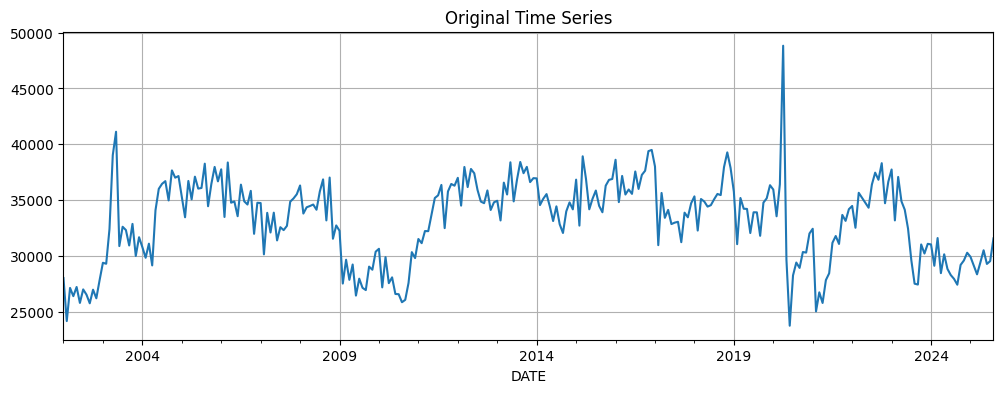

In [ ]:
series.plot(title="Original Time Series")
plt.show()

## إحصاءات وصفية

هذه الإحصاءات تساعدنا على فهم القيم المركزية والانتشار.

In [ ]:
display(series.describe())

,Value
count,284.000000
mean,33197.013810
std,3662.936429
min,23757.512200
25%,30377.515975
50%,34044.405250
75%,35863.064000
max,48826.671800


## استكشاف توزيع القيم

هنا نريد أن نرى كيف تتوزع القيم:

- هل التوزيع قريب من الطبيعي؟
- هل يوجد انحراف؟
- هل هناك قيم متطرفة؟
- هل البيانات متمركزة حول متوسط معين أم متباعدة؟

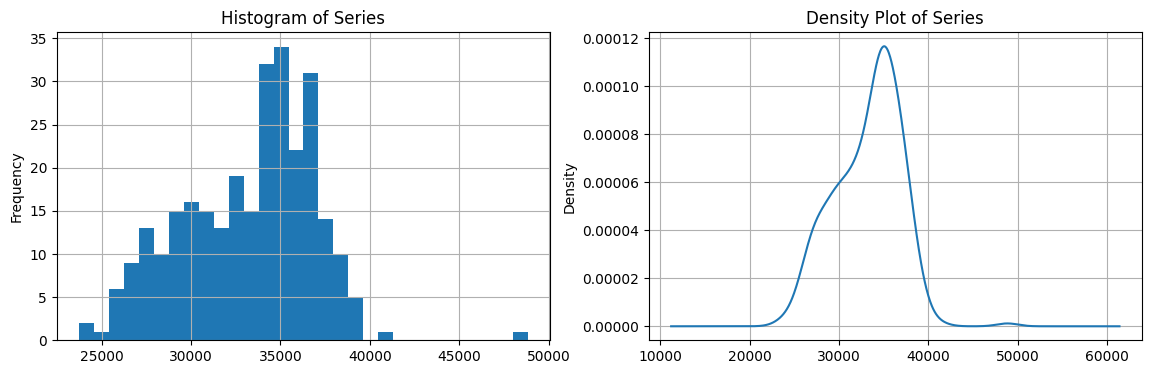

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

series.plot(kind='hist', bins=30, ax=ax[0], title='Histogram of Series')
series.plot(kind='kde', ax=ax[1], title='Density Plot of Series')

plt.show()

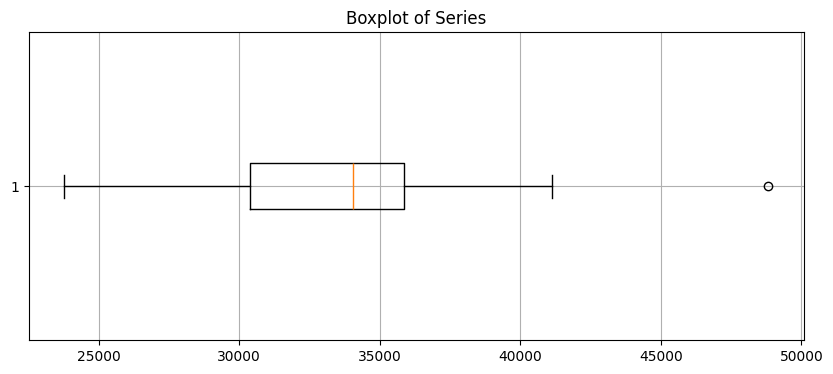

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(series.dropna(), vert=False)
plt.title("Boxplot of Series")
plt.show()

## تفسير هذه الرسومات

- **Histogram**: يوضح توزيع القيم وتكرارها
- **Density Plot**: يوضح الشكل العام للتوزيع
- **Boxplot**: يساعد في اكتشاف القيم الشاذة والانحراف

## فحص الثبات (Stationarity)

الثبات يعني أن الخصائص الإحصائية للسلسلة لا تتغير بمرور الزمن، مثل:

- المتوسط
- التباين
- الارتباط الذاتي

كثير من النماذج مثل:
- ARMA
- ARIMA
- SARIMA

تعمل بشكل أفضل عندما تكون السلسلة ثابتة أو قريبة من الثبات.

سنستخدم اختبار **ADF - Augmented Dickey Fuller**.

In [ ]:
def adf_report(x, title="ADF Test"):
    x = x.dropna()
    result = adfuller(x)

    stat = result[0]
    p_value = result[1]
    used_lag = result[2]
    n_obs = result[3]
    critical_values = result[4]

    print(f"===== {title} =====")
    print(f"ADF Statistic : {stat:.6f}")
    print(f"p-value       : {p_value:.6f}")
    print(f"Used Lag      : {used_lag}")
    print(f"N Observations: {n_obs}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.6f}")

    if p_value <= 0.05:
        print("Conclusion    : السلسلة ثابتة ✅")
    else:
        print("Conclusion    : السلسلة غير ثابتة ❌")

In [ ]:
adf_report(series, "ADF on Original Series")

===== ADF on Original Series =====
ADF Statistic : -3.703424
p-value       : 0.004065
Used Lag      : 12
N Observations: 271
Critical Values:
   1%: -3.454713
   5%: -2.872265
   10%: -2.572485
Conclusion    : السلسلة ثابتة ✅


## Feature Engineering

In [ ]:
oil_df_feature = oil_df.copy()
oil_df_feature.head()

,Energy Product Name,Flow breakdown,Unit of Measure,Value
DATE,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025
2002-02-01,Crude Oil,Exports,KL,24172.4697
2002-03-01,Crude Oil,Exports,KL,27141.8805
2002-04-01,Crude Oil,Exports,KL,26404.6552
2002-05-01,Crude Oil,Exports,KL,27225.6670


In [ ]:
oil_df_feature["Year"] = oil_df_feature.index.year
oil_df_feature["Month"] = oil_df_feature.index.month
oil_df_feature["Day"] = oil_df_feature.index.day
oil_df_feature["Day of Week"] = oil_df_feature.index.dayofweek
oil_df_feature["Quarter"] = oil_df_feature.index.quarter
oil_df_feature["Day Name"] = oil_df_feature.index.day_name()
oil_df_feature

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name
DATE,,,,,,,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025,2002,1,1,1,1,Tuesday
2002-02-01,Crude Oil,Exports,KL,24172.4697,2002,2,1,4,1,Friday
2002-03-01,Crude Oil,Exports,KL,27141.8805,2002,3,1,4,1,Friday
2002-04-01,Crude Oil,Exports,KL,26404.6552,2002,4,1,0,2,Monday
2002-05-01,Crude Oil,Exports,KL,27225.6670,2002,5,1,2,2,Wednesday
...,...,...,...,...,...,...,...,...,...,...
2025-04-01,Crude Oil,Exports,KL,29409.5202,2025,4,1,1,2,Tuesday
2025-05-01,Crude Oil,Exports,KL,30513.0529,2025,5,1,3,2,Thursday
2025-06-01,Crude Oil,Exports,KL,29290.2795,2025,6,1,6,2,Sunday


In [ ]:
oil_df_feature["Lag 1"] = oil_df_feature["Value"].shift(1)
oil_df_feature["Lag 3"] = oil_df_feature["Value"].shift(3)
oil_df_feature["Lag 7"] = oil_df_feature["Value"].shift(7)
oil_df_feature

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name,Lag 1,Lag 3,Lag 7
DATE,,,,,,,,,,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025,2002,1,1,1,1,Tuesday,NaN,NaN,NaN
2002-02-01,Crude Oil,Exports,KL,24172.4697,2002,2,1,4,1,Friday,28024.1025,NaN,NaN
2002-03-01,Crude Oil,Exports,KL,27141.8805,2002,3,1,4,1,Friday,24172.4697,NaN,NaN
2002-04-01,Crude Oil,Exports,KL,26404.6552,2002,4,1,0,2,Monday,27141.8805,28024.1025,NaN
2002-05-01,Crude Oil,Exports,KL,27225.6670,2002,5,1,2,2,Wednesday,26404.6552,24172.4697,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,Crude Oil,Exports,KL,29409.5202,2025,4,1,1,2,Tuesday,28359.2483,29931.4764,27430.1250
2025-05-01,Crude Oil,Exports,KL,30513.0529,2025,5,1,3,2,Thursday,29409.5202,29144.9649,29202.0414
2025-06-01,Crude Oil,Exports,KL,29290.2795,2025,6,1,6,2,Sunday,30513.0529,28359.2483,29600.3053


In [ ]:
oil_df_feature["Rolling Mean 7"] = oil_df_feature["Value"].shift(1).rolling(window=7).mean()
oil_df_feature["Rolling Std 7"] = oil_df_feature["Value"].shift(1).rolling(window=7).std()
oil_df_feature["Expanding Mean"] = oil_df_feature["Value"].shift(1).expanding().mean()
oil_df_feature["Expanding Std"] = oil_df_feature["Value"].shift(1).expanding().std()
oil_df_feature

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std
DATE,,,,,,,,,,,,,,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025,2002,1,1,1,1,Tuesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-02-01,Crude Oil,Exports,KL,24172.4697,2002,2,1,4,1,Friday,28024.1025,NaN,NaN,NaN,NaN,28024.102500,NaN
2002-03-01,Crude Oil,Exports,KL,27141.8805,2002,3,1,4,1,Friday,24172.4697,NaN,NaN,NaN,NaN,26098.286100,2723.515672
2002-04-01,Crude Oil,Exports,KL,26404.6552,2002,4,1,0,2,Monday,27141.8805,28024.1025,NaN,NaN,NaN,26446.150900,2017.869808
2002-05-01,Crude Oil,Exports,KL,27225.6670,2002,5,1,2,2,Wednesday,26404.6552,24172.4697,NaN,NaN,NaN,26435.776975,1647.714432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,Crude Oil,Exports,KL,29409.5202,2025,4,1,1,2,Tuesday,28359.2483,29931.4764,27430.1250,29137.060929,974.746674,33253.115843,3669.517687
2025-05-01,Crude Oil,Exports,KL,30513.0529,2025,5,1,3,2,Thursday,29409.5202,29144.9649,29202.0414,29419.831671,619.364622,33239.388715,3670.130603
2025-06-01,Crude Oil,Exports,KL,29290.2795,2025,6,1,6,2,Sunday,30513.0529,28359.2483,29600.3053,29607.119029,730.734720,33229.686453,3667.179247


In [ ]:
oil_df_feature[["Value","Lag 1",
                "Lag 3","Lag 7","Rolling Mean 7",
                "Rolling Std 7","Expanding Mean",
                "Expanding Std"]].head(10)

,Value,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std
DATE,,,,,,,,
2002-01-01,28024.1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-02-01,24172.4697,28024.1025,NaN,NaN,NaN,NaN,28024.102500,NaN
2002-03-01,27141.8805,24172.4697,NaN,NaN,NaN,NaN,26098.286100,2723.515672
2002-04-01,26404.6552,27141.8805,28024.1025,NaN,NaN,NaN,26446.150900,2017.869808
2002-05-01,27225.6670,26404.6552,24172.4697,NaN,NaN,NaN,26435.776975,1647.714432
2002-06-01,25798.9125,27225.6670,27141.8805,NaN,NaN,NaN,26593.754980,1470.036526
2002-07-01,27008.8079,25798.9125,26404.6552,NaN,NaN,NaN,26461.281233,1354.290099
2002-08-01,26540.5895,27008.8079,27225.6670,28024.1025,26539.499329,1253.492941,26539.499329,1253.492941
2002-09-01,25765.5251,26540.5895,25798.9125,24172.4697,26327.568900,1073.081263,26539.635600,1160.509023


In [ ]:
oil_df_feature[["Value","Lag 1",
                "Lag 3","Lag 7","Rolling Mean 7",
                "Rolling Std 7","Expanding Mean",
                "Expanding Std"]].tail(10)

,Value,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std
DATE,,,,,,,,
2024-11-01,29600.3053,29202.0414,27950.1733,28465.1340,28619.692657,888.152505,33322.233796,3665.543652
2024-12-01,30291.2652,29600.3053,27430.1250,30153.2640,28781.859986,956.252609,33308.699510,3665.725936
2025-01-01,29931.4764,30291.2652,29202.0414,28841.9346,28801.574443,990.063030,33297.766777,3663.559968
2025-02-01,29144.9649,29931.4764,29600.3053,28295.1763,28957.223271,1079.105525,33285.614104,3662.506221
2025-03-01,28359.2483,29144.9649,30291.2652,27950.1733,29078.621643,1039.277809,33270.719683,3664.314203
2025-04-01,29409.5202,28359.2483,29931.4764,27430.1250,29137.060929,974.746674,33253.115843,3669.517687
2025-05-01,30513.0529,29409.5202,29144.9649,29202.0414,29419.831671,619.364622,33239.388715,3670.130603
2025-06-01,29290.2795,30513.0529,28359.2483,29600.3053,29607.119029,730.734720,33229.686453,3667.179247
2025-07-01,29542.1158,29290.2795,29409.5202,30291.2652,29562.829629,740.545901,33215.716924,3668.157155


In [ ]:
oil_df_feature.index

DatetimeIndex(['2002-01-01', '2002-02-01', '2002-03-01', '2002-04-01',
               '2002-05-01', '2002-06-01', '2002-07-01', '2002-08-01',
               '2002-09-01', '2002-10-01',
               ...
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01'],
              dtype='datetime64[ns]', name='DATE', length=284, freq=None)

In [ ]:
oil_df_feature.columns

Index(['Energy Product Name', 'Flow breakdown', 'Unit of Measure', 'Value',
       'Year', 'Month', 'Day', 'Day of Week', 'Quarter', 'Day Name', 'Lag 1',
       'Lag 3', 'Lag 7', 'Rolling Mean 7', 'Rolling Std 7', 'Expanding Mean',
       'Expanding Std'],
      dtype='object')

In [ ]:
oil_df_feature.shape

(284, 17)

In [ ]:
oil_df_feature.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 284 entries, 2002-01-01 to 2025-08-01
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Energy Product Name  284 non-null    object 
 1   Flow breakdown       284 non-null    object 
 2   Unit of Measure      284 non-null    object 
 3   Value                284 non-null    float64
 4   Year                 284 non-null    int32  
 5   Month                284 non-null    int32  
 6   Day                  284 non-null    int32  
 7   Day of Week          284 non-null    int32  
 8   Quarter              284 non-null    int32  
 9   Day Name             284 non-null    object 
 10  Lag 1                283 non-null    float64
 11  Lag 3                281 non-null    float64
 12  Lag 7                277 non-null    float64
 13  Rolling Mean 7       277 non-null    float64
 14  Rolling Std 7        277 non-null    float64
 15  Expanding Mean       

In [ ]:
oil_df_feature.describe()

,Value,Year,Month,Day,Day of Week,Quarter,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std
count,284.000000,284.000000,284.000000,284.0,284.000000,284.000000,283.000000,281.000000,277.000000,277.000000,277.000000,283.000000,282.000000
mean,33197.013810,2013.338028,6.443662,1.0,3.014085,2.482394,33202.736002,33229.686453,33285.614104,33314.973180,1813.436044,32502.016832,3664.693482
std,3662.936429,6.845996,3.446768,0.0,1.998183,1.116709,3668.153424,3667.179247,3662.506221,3002.084590,1200.287530,1709.352215,567.942670
min,23757.512200,2002.000000,1.000000,1.0,0.000000,1.000000,23757.512200,23757.512200,23757.512200,26327.568900,424.539785,26098.286100,1014.465436
25%,30377.515975,2007.000000,3.000000,1.0,1.000000,1.000000,30370.123050,30513.052900,30888.104600,31017.815671,1167.276219,32462.938846,3631.955591
50%,34044.405250,2013.000000,6.000000,1.0,3.000000,2.000000,34096.155700,34121.911700,34140.990200,34208.173771,1467.003897,33076.655598,3678.558892
75%,35863.064000,2019.000000,9.000000,1.0,5.000000,3.000000,35865.528300,35870.456900,35909.885800,35785.126043,1970.284667,33479.149392,3804.421459
max,48826.671800,2025.000000,12.000000,1.0,6.000000,4.000000,48826.671800,48826.671800,48826.671800,37909.222643,8225.436957,33774.285351,4613.087830


In [ ]:
oil_df_feature.isnull().sum()

,0
Energy Product Name,0
Flow breakdown,0
Unit of Measure,0
Value,0
Year,0
Month,0
Day,0
Day of Week,0
Quarter,0
Day Name,0


In [ ]:
oil_df_feature.head(10)

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std
DATE,,,,,,,,,,,,,,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025,2002,1,1,1,1,Tuesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-02-01,Crude Oil,Exports,KL,24172.4697,2002,2,1,4,1,Friday,28024.1025,NaN,NaN,NaN,NaN,28024.102500,NaN
2002-03-01,Crude Oil,Exports,KL,27141.8805,2002,3,1,4,1,Friday,24172.4697,NaN,NaN,NaN,NaN,26098.286100,2723.515672
2002-04-01,Crude Oil,Exports,KL,26404.6552,2002,4,1,0,2,Monday,27141.8805,28024.1025,NaN,NaN,NaN,26446.150900,2017.869808
2002-05-01,Crude Oil,Exports,KL,27225.6670,2002,5,1,2,2,Wednesday,26404.6552,24172.4697,NaN,NaN,NaN,26435.776975,1647.714432
2002-06-01,Crude Oil,Exports,KL,25798.9125,2002,6,1,5,2,Saturday,27225.6670,27141.8805,NaN,NaN,NaN,26593.754980,1470.036526
2002-07-01,Crude Oil,Exports,KL,27008.8079,2002,7,1,0,3,Monday,25798.9125,26404.6552,NaN,NaN,NaN,26461.281233,1354.290099
2002-08-01,Crude Oil,Exports,KL,26540.5895,2002,8,1,3,3,Thursday,27008.8079,27225.6670,28024.1025,26539.499329,1253.492941,26539.499329,1253.492941
2002-09-01,Crude Oil,Exports,KL,25765.5251,2002,9,1,6,3,Sunday,26540.5895,25798.9125,24172.4697,26327.568900,1073.081263,26539.635600,1160.509023


In [ ]:
oil_df_feature.tail(10)

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std
DATE,,,,,,,,,,,,,,,,,
2024-11-01,Crude Oil,Exports,KL,29600.3053,2024,11,1,4,4,Friday,29202.0414,27950.1733,28465.1340,28619.692657,888.152505,33322.233796,3665.543652
2024-12-01,Crude Oil,Exports,KL,30291.2652,2024,12,1,6,4,Sunday,29600.3053,27430.1250,30153.2640,28781.859986,956.252609,33308.699510,3665.725936
2025-01-01,Crude Oil,Exports,KL,29931.4764,2025,1,1,2,1,Wednesday,30291.2652,29202.0414,28841.9346,28801.574443,990.063030,33297.766777,3663.559968
2025-02-01,Crude Oil,Exports,KL,29144.9649,2025,2,1,5,1,Saturday,29931.4764,29600.3053,28295.1763,28957.223271,1079.105525,33285.614104,3662.506221
2025-03-01,Crude Oil,Exports,KL,28359.2483,2025,3,1,5,1,Saturday,29144.9649,30291.2652,27950.1733,29078.621643,1039.277809,33270.719683,3664.314203
2025-04-01,Crude Oil,Exports,KL,29409.5202,2025,4,1,1,2,Tuesday,28359.2483,29931.4764,27430.1250,29137.060929,974.746674,33253.115843,3669.517687
2025-05-01,Crude Oil,Exports,KL,30513.0529,2025,5,1,3,2,Thursday,29409.5202,29144.9649,29202.0414,29419.831671,619.364622,33239.388715,3670.130603
2025-06-01,Crude Oil,Exports,KL,29290.2795,2025,6,1,6,2,Sunday,30513.0529,28359.2483,29600.3053,29607.119029,730.734720,33229.686453,3667.179247
2025-07-01,Crude Oil,Exports,KL,29542.1158,2025,7,1,1,3,Tuesday,29290.2795,29409.5202,30291.2652,29562.829629,740.545901,33215.716924,3668.157155


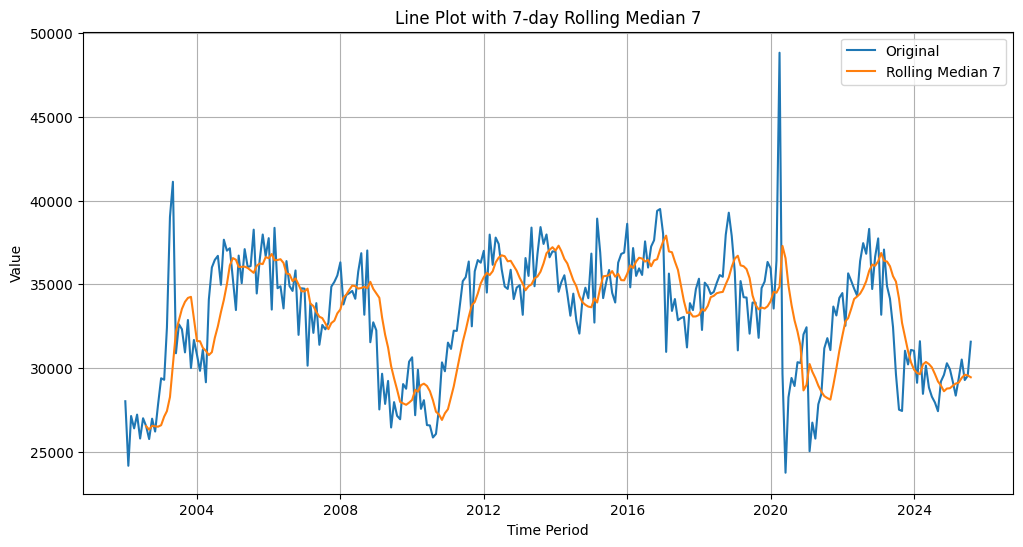

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(oil_df.index, oil_df['Value'])
plt.plot(oil_df_feature.index, oil_df_feature['Rolling Mean 7'])
plt.legend(['Original', 'Rolling Median 7'])
plt.xlabel('Time Period')
plt.ylabel('Value')
plt.title('Line Plot with 7-day Rolling Median 7')
plt.show()

In [ ]:
series_oil = oil_df['Value'].copy()
series_oil

,Value
DATE,
2002-01-01,28024.1025
2002-02-01,24172.4697
2002-03-01,27141.8805
2002-04-01,26404.6552
2002-05-01,27225.6670
...,...
2025-04-01,29409.5202
2025-05-01,30513.0529
2025-06-01,29290.2795


In [ ]:
series_oil

,Value
DATE,
2002-01-01,28024.1025
2002-02-01,24172.4697
2002-03-01,27141.8805
2002-04-01,26404.6552
2002-05-01,27225.6670
...,...
2025-04-01,29409.5202
2025-05-01,30513.0529
2025-06-01,29290.2795


In [ ]:
series_oil = series_oil.squeeze()

In [ ]:
print(type(series_oil))

<class 'pandas.core.series.Series'>


In [ ]:
groups = series_oil.groupby(Grouper(freq='YE'))

year_list = []

for name, group in groups:
    year_series = pd.Series(group.reset_index(drop=True).values, name=name.year)
    year_list.append(year_series)

years_df = pd.concat(year_list, axis=1)

years_df.head()

,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,28024.1025,29394.2574,30798.9125,35323.3807,37758.1163,34741.8042,36314.0322,32257.7824,30646.1255,31523.4189,...,38615.6953,38014.4043,35338.1666,35752.1702,35949.3148,32440.1412,34480.5876,37743.3305,31035.4860,29931.4764
1,24172.4697,29305.2243,29840.0585,33467.5188,33494.2288,30146.5865,33800.5978,27533.4669,27190.6897,31148.2082,...,34824.1598,30970.1421,32278.9278,31059.1752,33556.2339,25040.5418,32528.2203,33187.0648,29125.4094,29144.9649
2,27141.8805,32415.4981,31104.4866,36718.1786,38374.1931,33864.5108,34362.3009,29665.3312,29901.9047,32233.1394,...,37166.6826,35643.7407,35101.5931,35195.2367,36427.3904,26747.5913,35658.5265,37077.9675,31607.2053,28359.2483
3,26404.6552,39025.0882,29156.7299,35071.0674,34770.5809,32104.3594,34474.8641,27864.1610,27568.4441,32223.6001,...,35505.1035,33416.0069,34875.5127,34231.6131,48826.6718,25794.1429,35209.3866,34894.5912,28465.1340,29409.5202
4,27225.6670,41124.3601,34096.1557,37102.6106,34884.7340,33879.2966,34608.7316,29236.5417,28088.1745,33706.7951,...,35954.2434,34125.7274,34421.4442,34214.4424,29670.2598,27841.7438,34746.7328,34145.4418,30153.2640,30513.0529


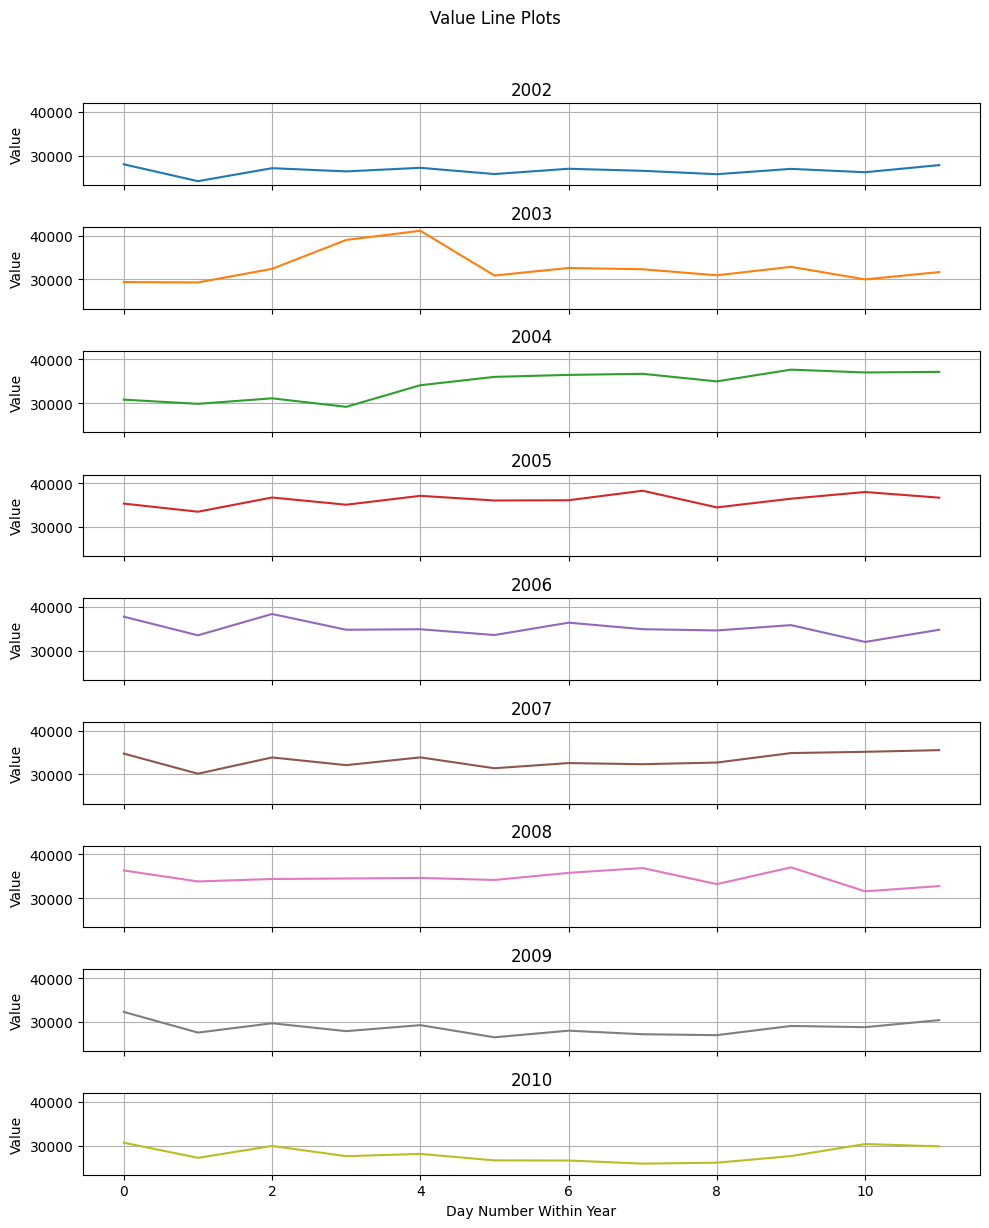

In [ ]:
axarr = years_df[[2002,2003,2004,2005,2006,2007,2008,2009,2010]].plot(
    subplots=True,
    legend=False,
    figsize=(10, 12),
    sharex=True,
    sharey=True
)

plt.suptitle('Value Line Plots', y=1.02)

for ax, col in zip(axarr, years_df.columns):
    ax.set_ylabel('Value')
    ax.set_title(str(col))

plt.xlabel('Day Number Within Year')
plt.tight_layout()
plt.show()

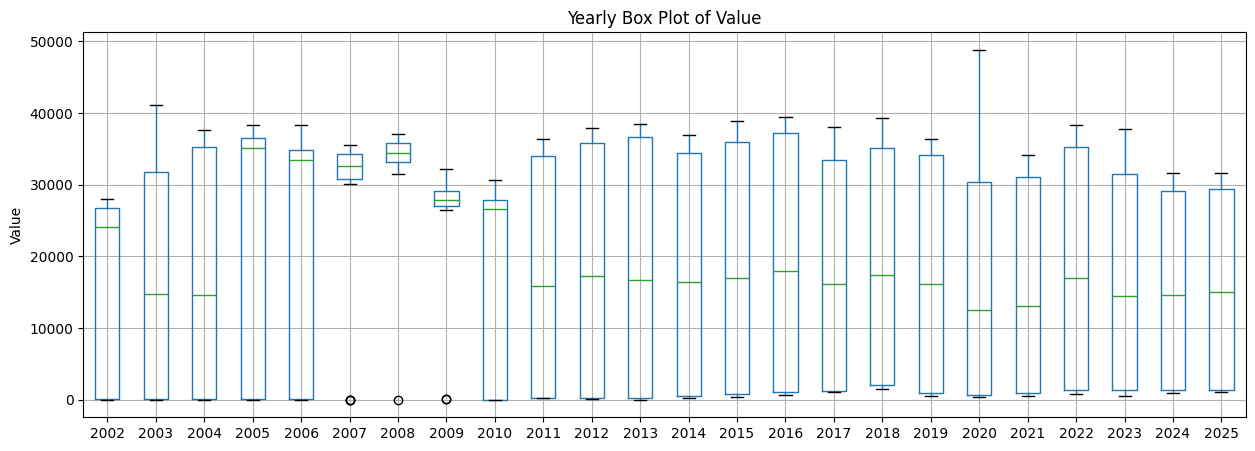

In [ ]:
groups = df.groupby(Grouper(freq='YE'))

year_list = []
for name, group in groups:
    year_series = pd.Series(group['Value'].reset_index(drop=True).values, name=name.year)
    year_list.append(year_series)

years = pd.concat(year_list, axis=1)

plt.figure(figsize=(15, 5))
years.boxplot()
plt.title("Yearly Box Plot of Value")
plt.ylabel("Value")
plt.show()

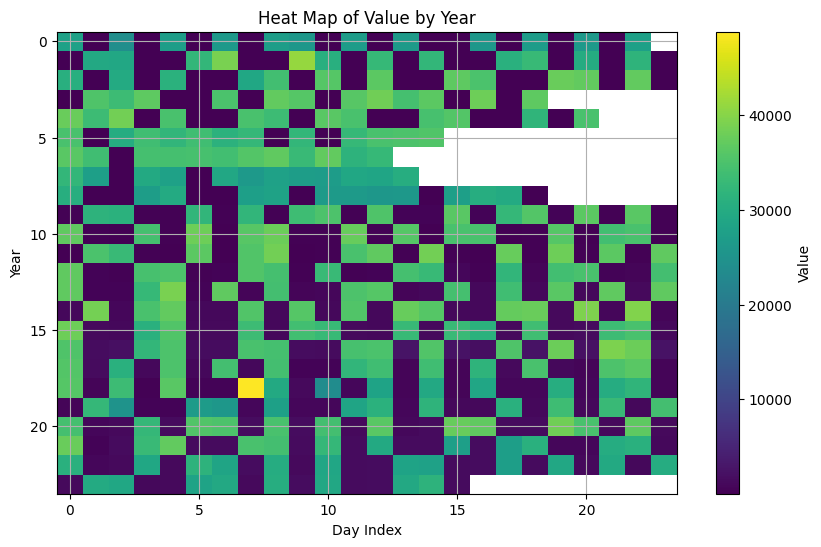

In [ ]:
groups = df.groupby(Grouper(freq='YE'))

year_list = []
for name, group in groups:
    year_series = pd.Series(group['Value'].reset_index(drop=True).values, name=name.year)
    year_list.append(year_series)

years = pd.concat(year_list, axis=1).T

plt.figure(figsize=(10, 6))
plt.imshow(years, aspect='auto', interpolation='none')
plt.title("Heat Map of Value by Year")
plt.xlabel("Day Index")
plt.ylabel("Year")
plt.colorbar(label="Value")
plt.show()

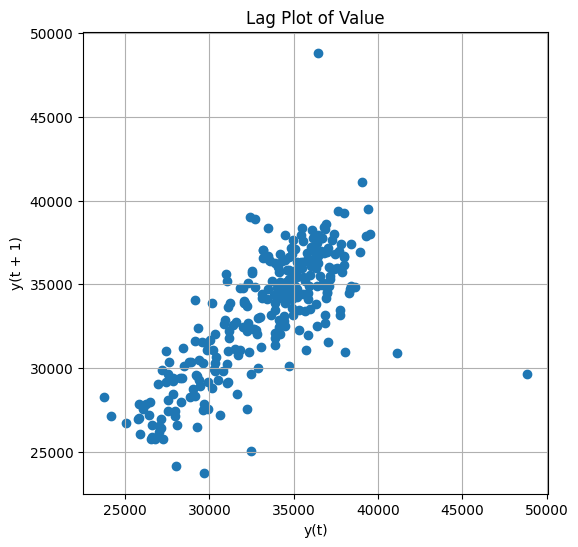

In [ ]:
plt.figure(figsize=(6, 6))
lag_plot(oil_df['Value'])
plt.title("Lag Plot of Value")
plt.show()

## Moving Average

In [ ]:
oil_df_feature["Moving Average 3"] = oil_df_feature["Value"].shift(1).rolling(window=3).mean()
oil_df_feature["Moving Average 6"] = oil_df_feature["Value"].shift(1).rolling(window=6).mean()
oil_df_feature["Moving Average 12"] = oil_df_feature["Value"].shift(1).rolling(window=12).mean()

In [ ]:
oil_df_feature.head(10)

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std,Moving Average 3,Moving Average 6,Moving Average 12
DATE,,,,,,,,,,,,,,,,,,,,
2002-01-01,Crude Oil,Exports,KL,28024.1025,2002,1,1,1,1,Tuesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-02-01,Crude Oil,Exports,KL,24172.4697,2002,2,1,4,1,Friday,28024.1025,NaN,NaN,NaN,NaN,28024.102500,NaN,NaN,NaN,NaN
2002-03-01,Crude Oil,Exports,KL,27141.8805,2002,3,1,4,1,Friday,24172.4697,NaN,NaN,NaN,NaN,26098.286100,2723.515672,NaN,NaN,NaN
2002-04-01,Crude Oil,Exports,KL,26404.6552,2002,4,1,0,2,Monday,27141.8805,28024.1025,NaN,NaN,NaN,26446.150900,2017.869808,26446.150900,NaN,NaN
2002-05-01,Crude Oil,Exports,KL,27225.6670,2002,5,1,2,2,Wednesday,26404.6552,24172.4697,NaN,NaN,NaN,26435.776975,1647.714432,25906.335133,NaN,NaN
2002-06-01,Crude Oil,Exports,KL,25798.9125,2002,6,1,5,2,Saturday,27225.6670,27141.8805,NaN,NaN,NaN,26593.754980,1470.036526,26924.067567,NaN,NaN
2002-07-01,Crude Oil,Exports,KL,27008.8079,2002,7,1,0,3,Monday,25798.9125,26404.6552,NaN,NaN,NaN,26461.281233,1354.290099,26476.411567,26461.281233,NaN
2002-08-01,Crude Oil,Exports,KL,26540.5895,2002,8,1,3,3,Thursday,27008.8079,27225.6670,28024.1025,26539.499329,1253.492941,26539.499329,1253.492941,26677.795800,26292.065467,NaN
2002-09-01,Crude Oil,Exports,KL,25765.5251,2002,9,1,6,3,Sunday,26540.5895,25798.9125,24172.4697,26327.568900,1073.081263,26539.635600,1160.509023,26449.436633,26686.752100,NaN


In [ ]:
oil_df_feature.dropna(inplace=True)
oil_df_feature

,Energy Product Name,Flow breakdown,Unit of Measure,Value,Year,Month,Day,Day of Week,Quarter,Day Name,Lag 1,Lag 3,Lag 7,Rolling Mean 7,Rolling Std 7,Expanding Mean,Expanding Std,Moving Average 3,Moving Average 6,Moving Average 12
DATE,,,,,,,,,,,,,,,,,,,,
2003-01-01,Crude Oil,Exports,KL,29394.2574,2003,1,1,2,1,Wednesday,27846.6724,26984.1648,25798.9125,26594.077471,748.261149,26593.943100,1044.613819,27014.902433,26726.604967,26593.943100
2003-02-01,Crude Oil,Exports,KL,29305.2243,2003,2,1,5,1,Saturday,29394.2574,26213.8701,27008.8079,27107.698171,1205.642651,26809.351892,1266.292034,27818.266633,27124.179883,26708.122675
2003-03-01,Crude Oil,Exports,KL,32415.4981,2003,3,1,5,1,Saturday,29305.2243,27846.6724,26540.5895,27435.757657,1459.875898,26987.628493,1387.481659,28848.718033,27584.952350,27135.852225
2003-04-01,Crude Oil,Exports,KL,39025.0882,2003,4,1,1,2,Tuesday,32415.4981,29394.2574,25765.5251,28275.030314,2304.100133,27349.486467,1936.934621,30371.659933,28693.281183,27575.320358
2003-05-01,Crude Oil,Exports,KL,41124.3601,2003,5,1,3,2,Thursday,39025.0882,29305.2243,26984.1648,30169.253614,4397.022085,28079.211575,3467.215177,33581.936867,30700.101750,28627.023108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,Crude Oil,Exports,KL,29409.5202,2025,4,1,1,2,Tuesday,28359.2483,29931.4764,27430.1250,29137.060929,974.746674,33253.115843,3669.517687,29145.229867,29421.550250,28972.092392
2025-05-01,Crude Oil,Exports,KL,30513.0529,2025,5,1,3,2,Thursday,29409.5202,29144.9649,29202.0414,29419.831671,619.364622,33239.388715,3670.130603,28971.244467,29456.130050,29050.791242
2025-06-01,Crude Oil,Exports,KL,29290.2795,2025,6,1,6,2,Sunday,30513.0529,28359.2483,29600.3053,29607.119029,730.734720,33229.686453,3667.179247,29427.273800,29608.254650,29080.773650


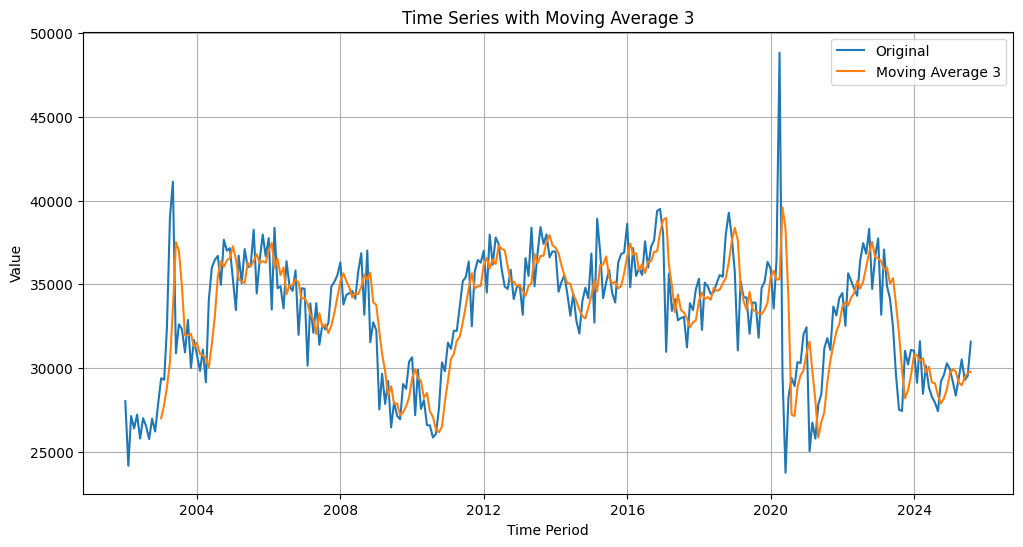

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(oil_df.index, oil_df['Value'])
plt.plot(oil_df_feature.index, oil_df_feature['Moving Average 3'])
plt.legend(['Original', 'Moving Average 3'])
plt.xlabel('Time Period')
plt.ylabel('Value')
plt.title('Time Series with Moving Average 3')
plt.show()

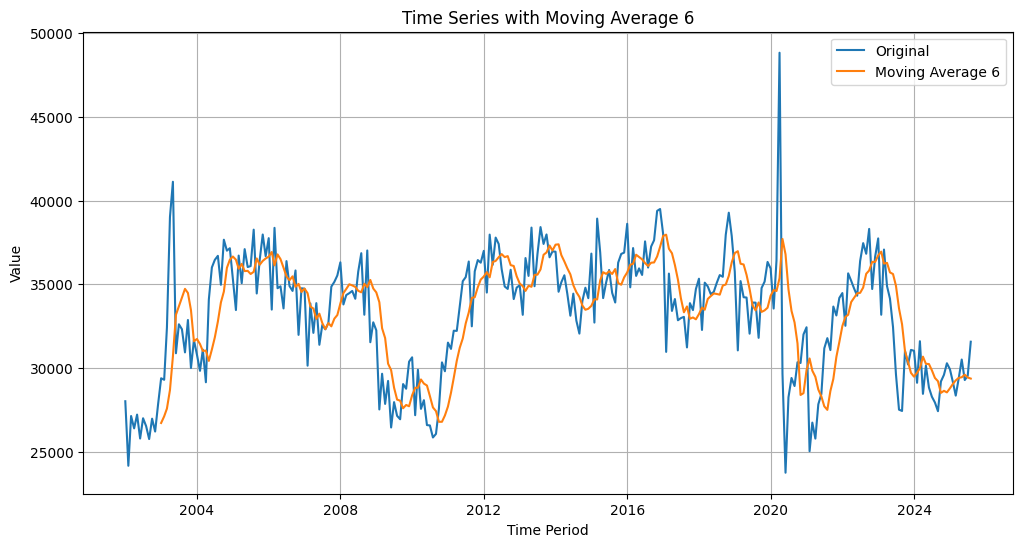

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(oil_df.index, oil_df['Value'])

plt.plot(oil_df_feature.index, oil_df_feature['Moving Average 6'])
plt.legend(['Original','Moving Average 6'])
plt.xlabel('Time Period')
plt.ylabel('Value')
plt.title('Time Series with Moving Average 6')
plt.show()

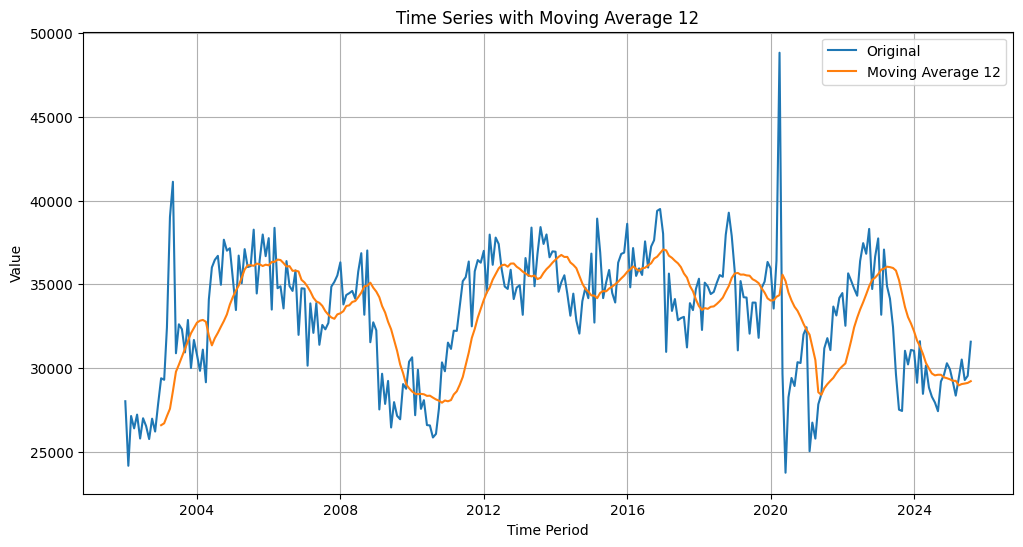

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(oil_df.index, oil_df['Value'])

plt.plot(oil_df_feature.index, oil_df_feature['Moving Average 12'])
plt.legend(['Original','Moving Average 12'])
plt.xlabel('Time Period')
plt.ylabel('Value')
plt.title('Time Series with Moving Average 12')
plt.show()

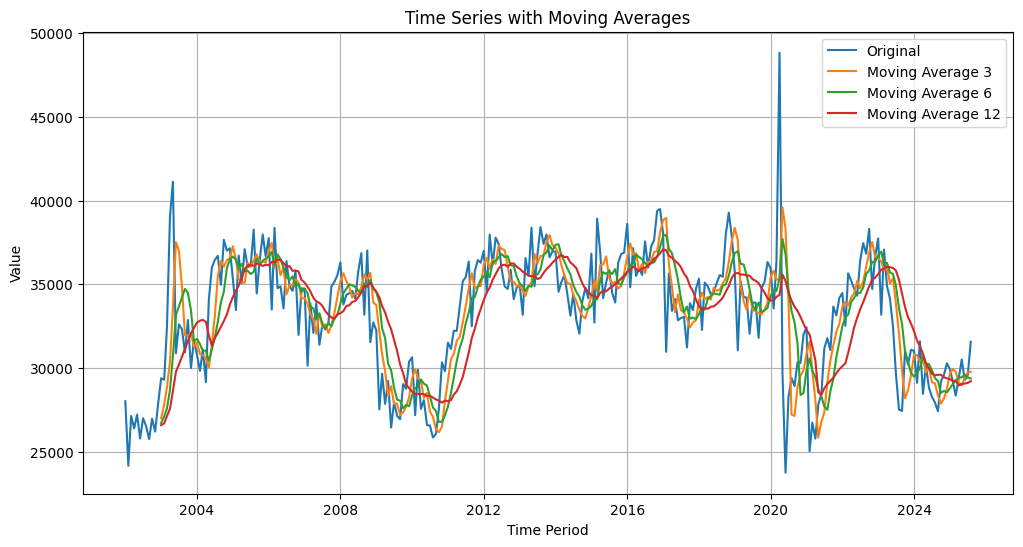

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(oil_df.index, oil_df['Value'])
plt.plot(oil_df_feature.index, oil_df_feature['Moving Average 3'])
plt.plot(oil_df_feature.index, oil_df_feature['Moving Average 6'])
plt.plot(oil_df_feature.index, oil_df_feature['Moving Average 12'])
plt.legend(['Original', 'Moving Average 3','Moving Average 6','Moving Average 12'])
plt.xlabel('Time Period')
plt.ylabel('Value')
plt.title('Time Series with Moving Averages')
plt.show()

## Power Transform

In [ ]:
# 1- Log
log_oil_df = np.log(oil_df['Value'])
log_oil_df

,Value
DATE,
2002-01-01,10.240820
2002-02-01,10.092970
2002-03-01,10.208833
2002-04-01,10.181296
2002-05-01,10.211915
...,...
2025-04-01,10.289074
2025-05-01,10.325910
2025-06-01,10.285011


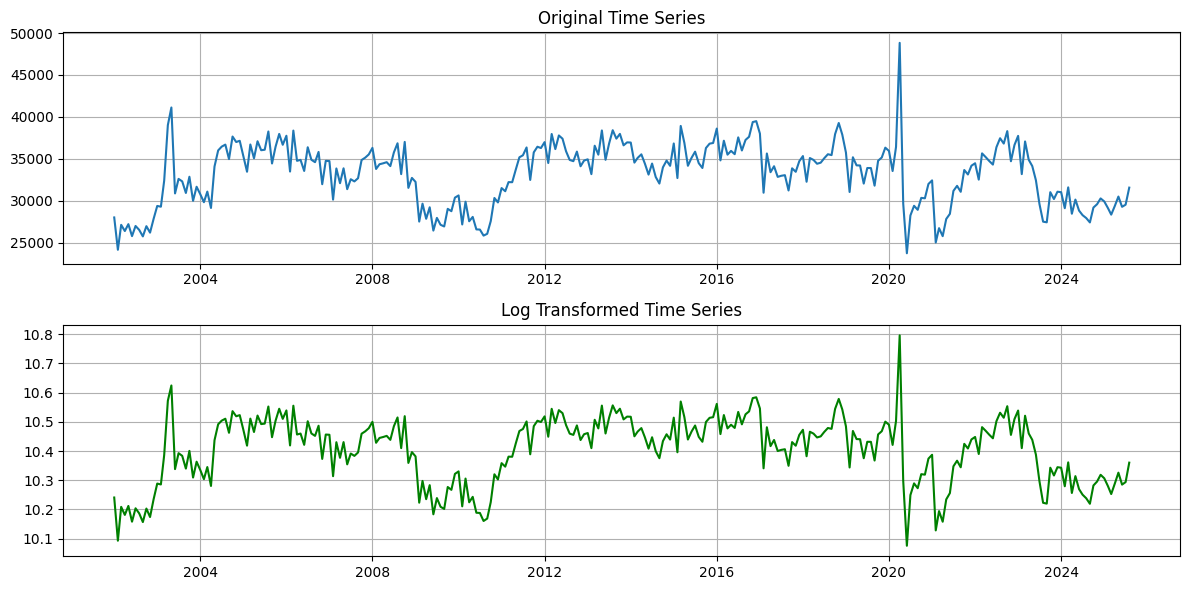

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(oil_df.index, oil_df['Value'])
plt.title('Original Time Series')

plt.subplot(2, 1, 2)
plt.plot(log_oil_df.index, log_oil_df, color='g')
plt.title('Log Transformed Time Series')

plt.tight_layout()
plt.show()

In [ ]:
# 2- Square Root
sqrt_oil_df = np.sqrt(oil_df['Value'])
sqrt_oil_df

,Value
DATE,
2002-01-01,167.404010
2002-02-01,155.474981
2002-03-01,164.747930
2002-04-01,162.495093
2002-05-01,165.002021
...,...
2025-04-01,171.492041
2025-05-01,174.679858
2025-06-01,171.144031


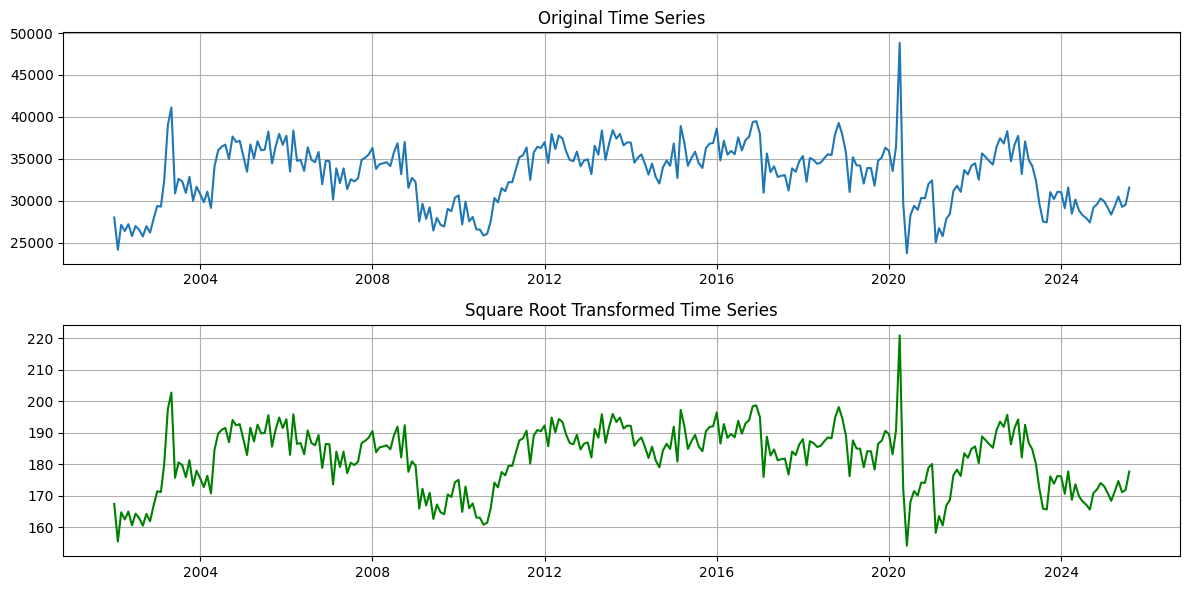

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(oil_df.index, oil_df['Value'])
plt.title('Original Time Series')

plt.subplot(2, 1, 2)
plt.plot(sqrt_oil_df.index, sqrt_oil_df, color='g')
plt.title('Square Root Transformed Time Series')

plt.tight_layout()
plt.show()

In [ ]:
# 3- Box-Cox
series_values = oil_df['Value'].squeeze()
boxcox_oil_df, lam = boxcox(series_values)
print("Best Lambda for Box-Cox:", lam)

Best Lambda for Box-Cox: 1.4931857666507382


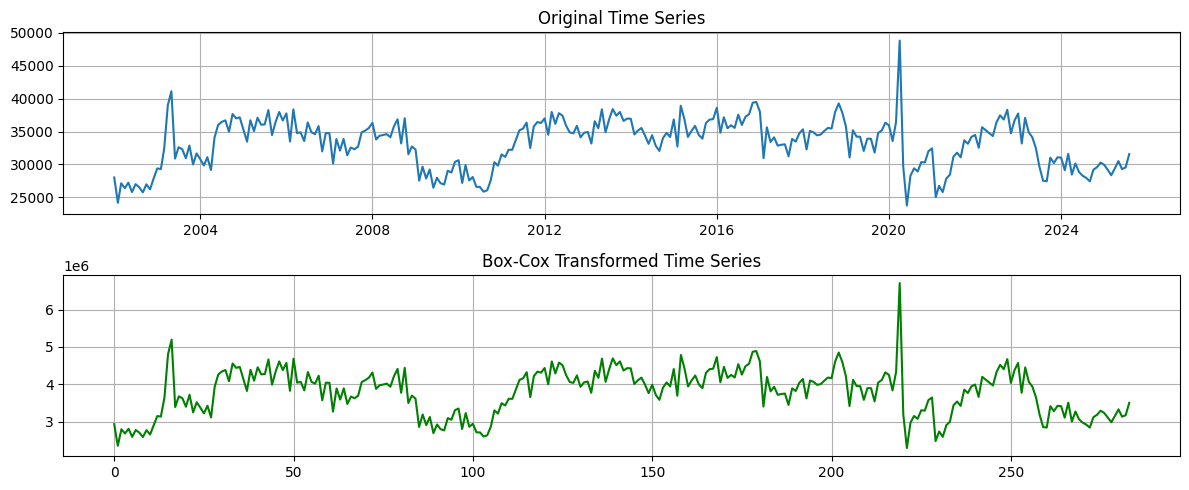

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(2, 1, 1)
plt.plot(oil_df.index, oil_df['Value'])
plt.title('Original Time Series')

plt.subplot(2, 1, 2)
plt.plot(boxcox_oil_df, color='g')
plt.title('Box-Cox Transformed Time Series')

plt.tight_layout()
plt.show()

## تحليل ACF و PACF

نستخدم:
- **ACF** لفحص الارتباط بين القيم الحالية والقيم السابقة
- **PACF** لفحص الارتباط الجزئي بعد إزالة تأثير الفجوات السابقة

هذه الرسومات تساعدنا في:
- تقدير معاملات **p**
- تقدير معاملات **q**
- فهم البنية الزمنية في السلسلة

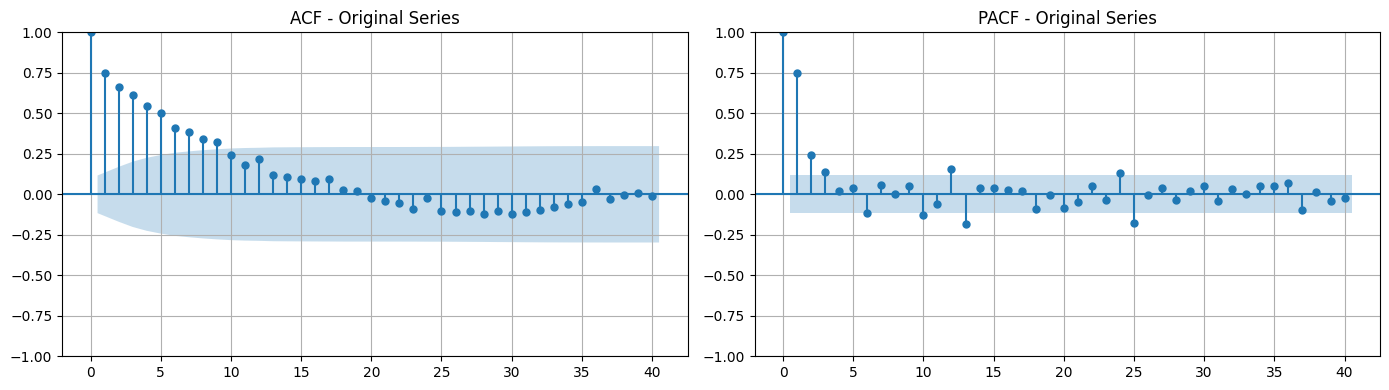

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(series.dropna(), lags=40, ax=ax[0])
ax[0].set_title("ACF - Original Series")

plot_pacf(series.dropna(), lags=40, method='ywm', ax=ax[1])
ax[1].set_title("PACF - Original Series")

plt.tight_layout()
plt.show()



## تفكيك السلسلة الزمنية

تفكيك السلسلة يساعدنا على فصلها إلى:

- **Trend**: الاتجاه العام
- **Seasonal**: الموسمية
- **Residual**: البواقي أو الجزء غير المفسر

نحتاج تحديد `period` حسب طبيعة البيانات:

- 12 إذا كانت البيانات شهرية وفيها نمط سنوي
- 7 إذا كانت يومية وفيها نمط أسبوعي
- 24 إذا كانت بيانات ساعية وفيها نمط يومي

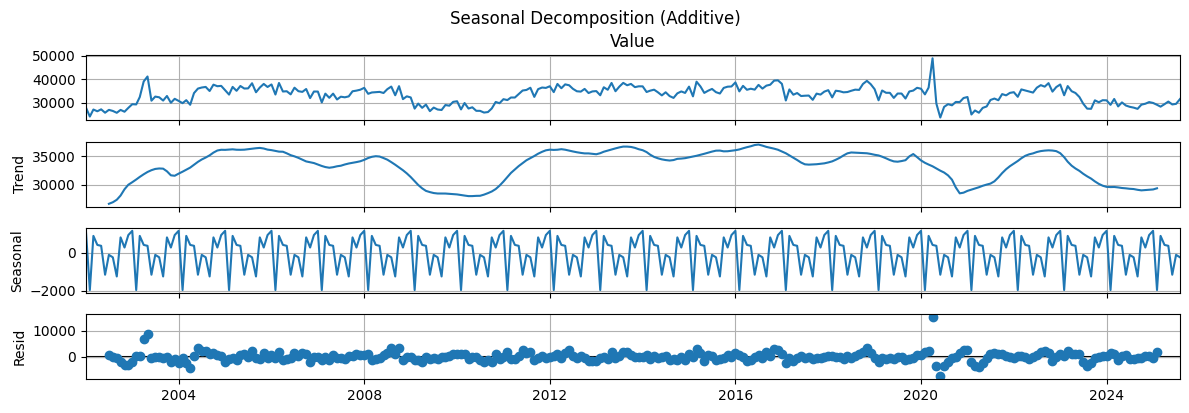

In [ ]:
period_guess = 12  # عدليها حسب بياناتك

decomp = seasonal_decompose(series.dropna(), model='additive', period=period_guess)
decomp.plot()
plt.suptitle("Seasonal Decomposition (Additive)", y=1.02)
plt.show()

## ملاحظات بعد التفكيك

من خلال الرسم نلاحظ:

- هل يوجد ترند واضح؟
- هل الموسمية قوية ومتكررة؟
- هل البواقي عشوائية أم ما زالت تحتوي نمطًا؟

إذا كانت السلسلة غير ثابتة، فسنحتاج إلى معالجتها قبل النمذجة.

## معالجة السلسلة الزمنية

إذا كانت السلسلة غير ثابتة، يمكننا تجربة:

1. **التفريق العادي** لإزالة الترند
2. **التفريق الموسمي** لإزالة الموسمية
3. **التفريق المختلط** عند وجود ترند وموسمية معًا

ثم نعيد اختبار الثبات بعد كل معالجة.

In [ ]:
# تفريق أول
series_d1 = series.diff()

# تفريق موسمي
series_D1 = series.diff(period_guess)

# تفريق عادي + موسمي
series_d1_D1 = series.diff().diff(period_guess)

NameError: name 'period_guess' is not defined

In [ ]:
adf_report(series_d1, "ADF after 1st Difference")
print()
adf_report(series_D1, f"ADF after Seasonal Difference (s={period_guess})")
print()
adf_report(series_d1_D1, f"ADF after 1st + Seasonal Difference (s={period_guess})")

===== ADF after 1st Difference =====
ADF Statistic : -5.354411
p-value       : 0.000004
Used Lag      : 11
N Observations: 271
Critical Values:
   1%: -3.454713
   5%: -2.872265
   10%: -2.572485
Conclusion    : السلسلة ثابتة ✅

===== ADF after Seasonal Difference (s=12) =====
ADF Statistic : -4.129446
p-value       : 0.000865
Used Lag      : 12
N Observations: 259
Critical Values:
   1%: -3.455853
   5%: -2.872765
   10%: -2.572752
Conclusion    : السلسلة ثابتة ✅

===== ADF after 1st + Seasonal Difference (s=12) =====
ADF Statistic : -7.188202
p-value       : 0.000000
Used Lag      : 12
N Observations: 258
Critical Values:
   1%: -3.455953
   5%: -2.872809
   10%: -2.572775
Conclusion    : السلسلة ثابتة ✅


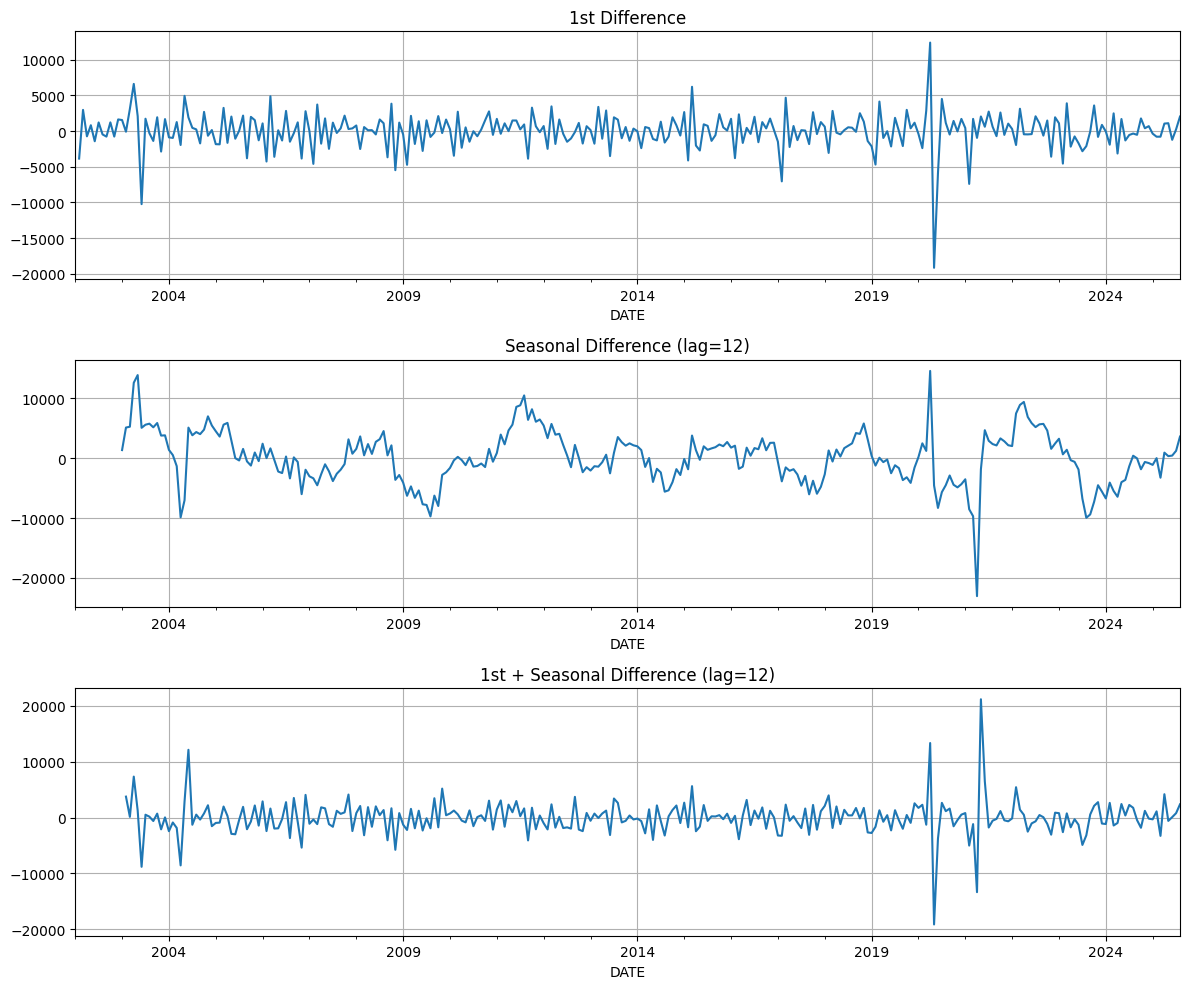

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

series_d1.plot(ax=ax[0], title="1st Difference")
series_D1.plot(ax=ax[1], title=f"Seasonal Difference (lag={period_guess})")
series_d1_D1.plot(ax=ax[2], title=f"1st + Seasonal Difference (lag={period_guess})")

plt.tight_layout()
plt.show()

## ملاحظة

- إذا أصبحت السلسلة ثابتة بعد **التفريق الأول** فهذا يدعم استخدام **ARIMA**
- إذا احتجنا أيضًا **تفريقًا موسميًا** فهذا يدعم استخدام **SARIMA**
- أما **ARMA** فيُفترض أن السلسلة أصلًا ثابتة، أو يتم تطبيقه على سلسلة تمت معالجتها لتصبح ثابتة

## تقسيم البيانات

سنحتفظ بآخر 30% من البيانات للاختبار حتى نقيس قدرة النموذج على التنبؤ في بيانات لم يرها أثناء التدريب.

In [ ]:
split_idx = int(len(series) * 0.7)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print("Train size:", len(train))
print("Test size :", len(test))

Train size: 198
Test size : 86


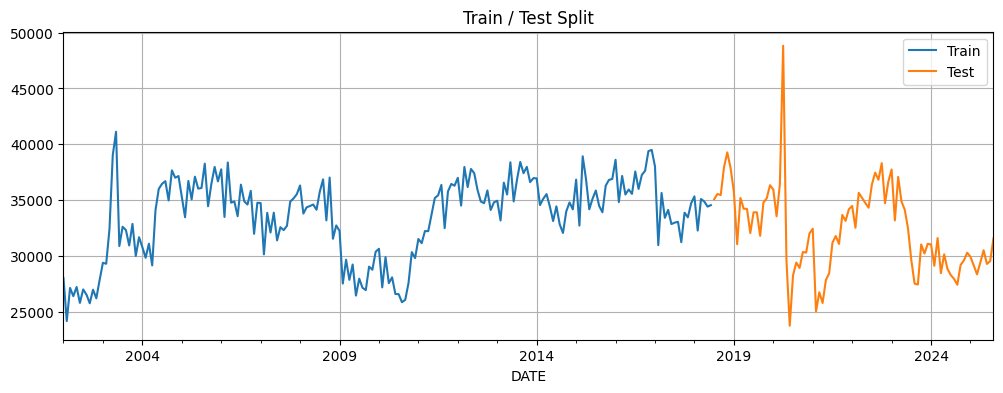

In [ ]:
plt.figure(figsize=(12, 4))
train.plot(label="Train")
test.plot(label="Test")
plt.title("Train / Test Split")
plt.legend()
plt.show()

## دوال التقييم

سنستخدم:
- **RMSE**
- **MAE**

للمقارنة بين النماذج.

In [ ]:
def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

## نموذج خط الأساس Baseline

قبل بناء النماذج المتقدمة، نحتاج مرجعًا بسيطًا نقارن به الأداء.

هنا سنستخدم **Persistence Model**:
> التنبؤ بالقيمة التالية = آخر قيمة حقيقية معروفة

In [ ]:
baseline_pred = test.shift(1).fillna(train.iloc[-1])

baseline_rmse = rmse(test.values, baseline_pred.values)
baseline_mae = mae(test.values, baseline_pred.values)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)

Baseline RMSE: 3241.014614833261
Baseline MAE : 1943.214438372093


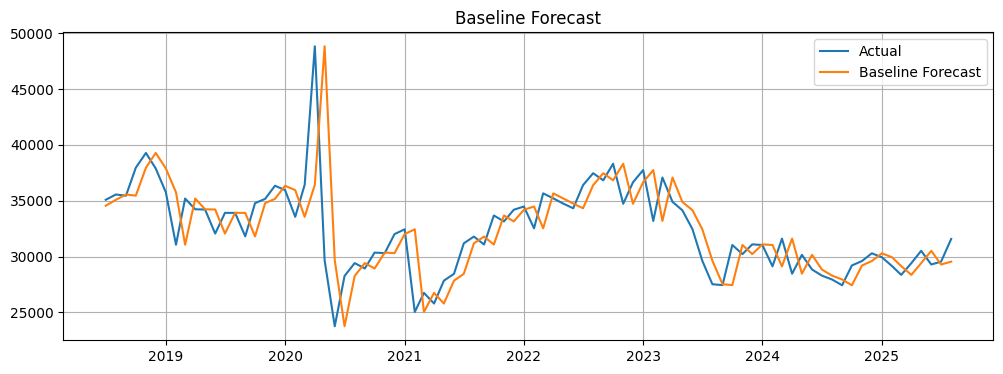

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, baseline_pred.values, label="Baseline Forecast")
plt.title("Baseline Forecast")
plt.legend()
plt.show()

## بناء نموذج ARMA

نموذج ARMA مناسب عندما تكون السلسلة **ثابتة**.

بما أن السلسلة الأصلية غالبًا غير ثابتة، سنبني ARMA على **السلسلة بعد التفريق الأول** ثم نعيدها إلى المستوى الأصلي عند التنبؤ.

In [ ]:
train_diff = train.diff().dropna()

p_range = range(0, 4)
q_range = range(0, 4)

best_arma_aic = np.inf
best_arma_order = None
arma_models = {}

for p in p_range:
    for q in q_range:
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(train_diff, order=(p, 0, q)).fit()
            arma_models[(p, q)] = model

            if model.aic < best_arma_aic:
                best_arma_aic = model.aic
                best_arma_order = (p, q)
        except:
            pass

print("Best ARMA order:", best_arma_order)
print("Best ARMA AIC  :", round(best_arma_aic, 3))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARMA order: (2, 3)
Best ARMA AIC  : 3531.416


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
arma_best = arma_models[best_arma_order]
print(arma_best.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  197
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -1758.708
Date:                Thu, 23 Apr 2026   AIC                           3531.416
Time:                        02:22:51   BIC                           3554.398
Sample:                    02-01-2002   HQIC                          3540.719
                         - 06-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.1989    118.954      0.279      0.780    -199.946     266.344
ar.L1         -1.7274      0.004   -449.357      0.000      -1.735      -1.720
ar.L2         -1.0000      0.000  -2369.991      0.0

In [ ]:
nsteps = len(test)
arma_diff_forecast = arma_best.get_forecast(steps=nsteps).predicted_mean

last_train_level = train.iloc[-1]
arma_forecast = last_train_level + arma_diff_forecast.cumsum()

arma_rmse = rmse(test.values, arma_forecast.values)
arma_mae = mae(test.values, arma_forecast.values)

print("ARMA RMSE:", arma_rmse)
print("ARMA MAE :", arma_mae)

ARMA RMSE: 5467.295392039125
ARMA MAE : 4368.963911972575


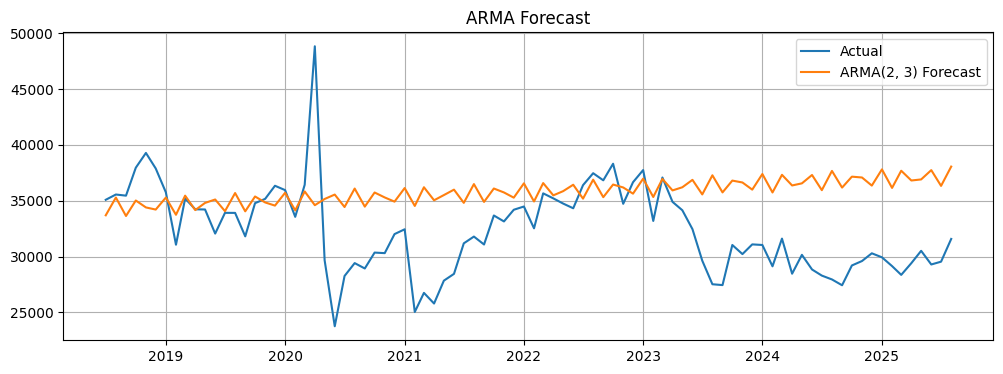

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arma_forecast.values, label=f"ARMA{best_arma_order} Forecast")
plt.title("ARMA Forecast")
plt.legend()
plt.show()

## بناء نموذج ARIMA

نموذج ARIMA يعالج وجود الترند باستخدام معامل التفريق `d`.

سنبحث عن أفضل توليفة من:
- `p`
- `d`
- `q`

اعتمادًا على **AIC**

In [ ]:
p = range(0, 4)
d = [0, 1, 2]
q = range(0, 4)

best_arima_aic = np.inf
best_arima_order = None
arima_models = {}

for order in itertools.product(p, d, q):
    try:
        model = ARIMA(train, order=order).fit()
        arima_models[order] = model

        if model.aic < best_arima_aic:
            best_arima_aic = model.aic
            best_arima_order = order
    except:
        pass

print("Best ARIMA order:", best_arima_order)
print("Best ARIMA AIC  :", round(best_arima_aic, 3))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order: (2, 1, 3)
Best ARIMA AIC  : 3542.412


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
arima_best = arima_models[best_arima_order]
print(arima_best.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  198
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -1765.206
Date:                Thu, 23 Apr 2026   AIC                           3542.412
Time:                        02:23:02   BIC                           3562.111
Sample:                    01-01-2002   HQIC                          3550.386
                         - 06-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7308      0.008   -210.720      0.000      -1.747      -1.715
ar.L2         -0.9998      0.002   -535.891      0.000      -1.003      -0.996
ma.L1          1.4690      0.085     17.317      0.0

In [ ]:
arima_fc = arima_best.get_forecast(steps=len(test))
arima_forecast = arima_fc.predicted_mean

arima_rmse = rmse(test.values, arima_forecast.values)
arima_mae = mae(test.values, arima_forecast.values)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE :", arima_mae)

ARIMA RMSE: 4381.495578915067
ARIMA MAE : 3461.1735922426947


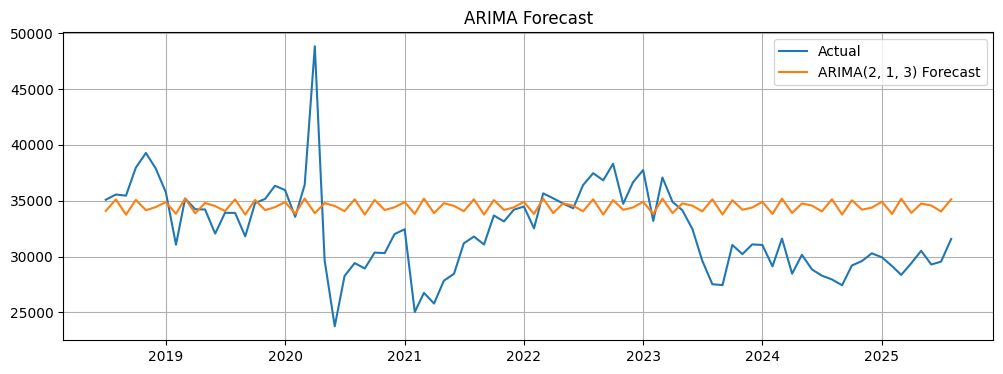

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arima_forecast.values, label=f"ARIMA{best_arima_order} Forecast")
plt.title("ARIMA Forecast")
plt.legend()
plt.show()

## بناء نموذج SARIMA

إذا كانت السلسلة تحتوي على **موسمية**، فإن SARIMA يكون أكثر ملاءمة لأنه يجمع بين:

- الجزء غير الموسمي `(p,d,q)`
- الجزء الموسمي `(P,D,Q,s)`

حيث:
- `s` يمثل طول الدورة الموسمية

In [ ]:
p = range(0, 4)
d = [0, 1]
q = range(0, 4)

P = range(0, 3)
D = [0, 1]
Q = range(0, 3)
s = period_guess

best_sarima_aic = np.inf
best_sarima_cfg = None
sarima_models = {}

for order in itertools.product(p, d, q):
    for seasonal_order in itertools.product(P, D, Q, [s]):
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            sarima_models[(order, seasonal_order)] = model

            if model.aic < best_sarima_aic:
                best_sarima_aic = model.aic
                best_sarima_cfg = (order, seasonal_order)
        except:
            pass

print("Best SARIMA config:", best_sarima_cfg)
print("Best SARIMA AIC   :", round(best_sarima_aic, 3))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best SARIMA config: ((0, 1, 3), (1, 1, 2, 12))
Best SARIMA AIC   : 2740.106


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarima_best = sarima_models[best_sarima_cfg]
print(sarima_best.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                   Value   No. Observations:                  198
Model:             SARIMAX(0, 1, 3)x(1, 1, [1, 2], 12)   Log Likelihood               -1363.053
Date:                                 Thu, 23 Apr 2026   AIC                           2740.106
Time:                                         02:38:22   BIC                           2761.500
Sample:                                     01-01-2002   HQIC                          2748.795
                                          - 06-01-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4069      0.099     -4.120      0.000      -0.601      -0

In [ ]:
sarima_fc = sarima_best.get_forecast(steps=len(test))
sarima_forecast = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()

sarima_rmse = rmse(test.values, sarima_forecast.values)
sarima_mae = mae(test.values, sarima_forecast.values)

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAE :", sarima_mae)

SARIMA RMSE: 4439.390333570344
SARIMA MAE : 3497.778211538652


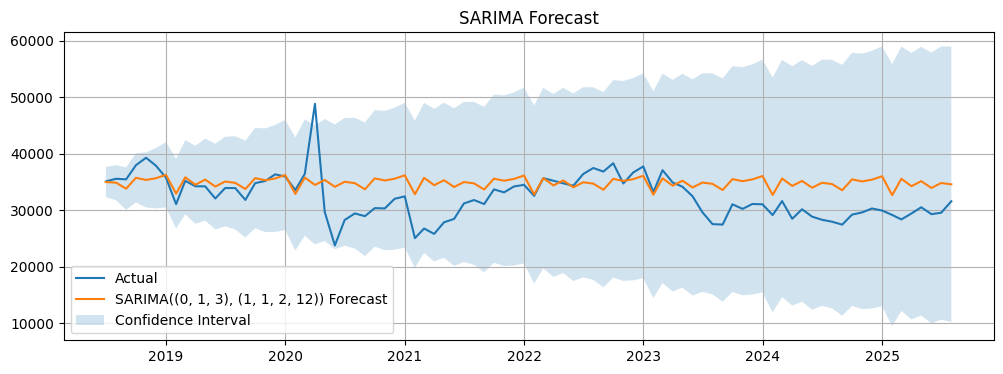

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, sarima_forecast.values, label=f"SARIMA{best_sarima_cfg} Forecast")
plt.fill_between(test.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.2, label="Confidence Interval")
plt.title("SARIMA Forecast")
plt.legend()
plt.show()

## مقارنة النماذج

سنقارن بين النماذج باستخدام:

- **RMSE**
- **MAE**
- **AIC** للنماذج الإحصائية

In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "ARMA", "ARIMA", "SARIMA"],
    "RMSE": [
        baseline_rmse,
        arma_rmse,
        arima_rmse,
        sarima_rmse
    ],
    "MAE": [
        baseline_mae,
        arma_mae,
        arima_mae,
        sarima_mae
    ],
    "AIC": [
        np.nan,
        float(arma_best.aic),
        float(arima_best.aic),
        float(sarima_best.aic)
    ],
    "Description": [
        "Persistence baseline",
        "ARMA on differenced series",
        "Handles non-seasonal trend",
        "Handles trend + seasonality"
    ]
})

results = results.sort_values("RMSE", ascending=True)
display(results)

,Model,RMSE,MAE,AIC,Description
0,Baseline,3241.014615,1943.214438,NaN,Persistence baseline
2,ARIMA,4381.495579,3461.173592,3542.411763,Handles non-seasonal trend
3,SARIMA,4439.390334,3497.778212,2740.106182,Handles trend + seasonality
1,ARMA,5467.295392,4368.963912,3531.415663,ARMA on differenced series


## اختيار أفضل نموذج

سنختار النموذج الأفضل بناءً على أقل قيمة **RMSE**.

In [ ]:
best_model_name = results.iloc[0]["Model"]
print("Best model based on RMSE:", best_model_name)

Best model based on RMSE: Baseline


In [ ]:
if best_model_name == "ARMA":
    best_model = arma_best
    best_model_label = f"ARMA{best_arma_order}"
elif best_model_name == "ARIMA":
    best_model = arima_best
    best_model_label = f"ARIMA{best_arima_order}"
elif best_model_name == "SARIMA":
    best_model = sarima_best
    best_model_label = f"SARIMA{best_sarima_cfg}"
else:
    best_model = None
    best_model_label = "Baseline"

print("Selected model:", best_model_label)

Selected model: Baseline


## تحليل بواقي الأخطاء

تحليل البواقي خطوة مهمة جدًا بعد بناء النموذج.

نريد أن تكون البواقي:

- عشوائية
- غير مترابطة
- متوسطها قريب من الصفر
- لا تحتوي نمطًا واضحًا

إذا كانت البواقي ما زالت تحتوي على بنية زمنية، فهذا يعني أن النموذج لم يلتقط كل المعلومات في السلسلة.

In [ ]:
if best_model_name == "ARMA":
    residuals = arma_best.resid
elif best_model_name == "ARIMA":
    residuals = arima_best.resid
elif best_model_name == "SARIMA":
    residuals = sarima_best.resid
else:
    residuals = test - baseline_pred

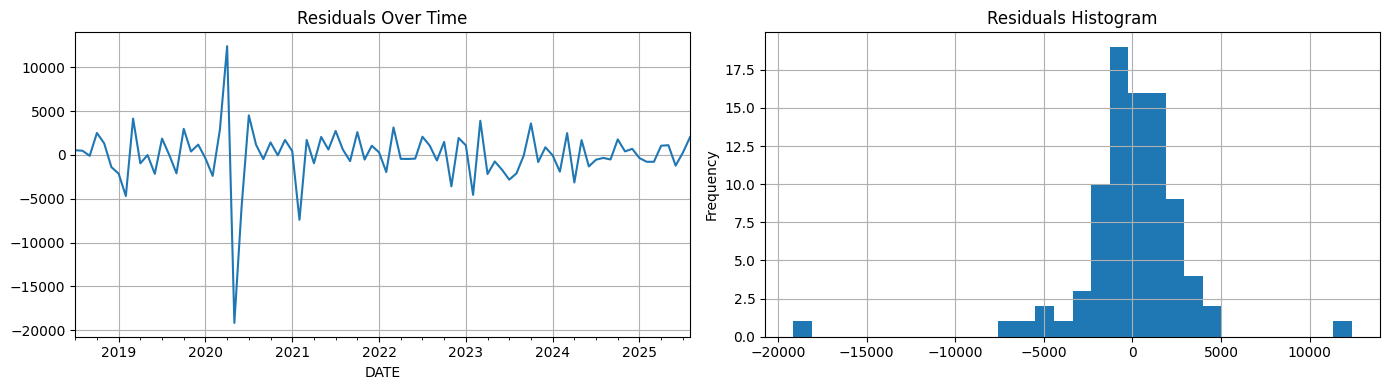

In [ ]:
residuals = pd.Series(residuals).dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

residuals.plot(ax=ax[0], title="Residuals Over Time")
residuals.plot(kind='hist', bins=30, ax=ax[1], title="Residuals Histogram")

plt.tight_layout()
plt.show()

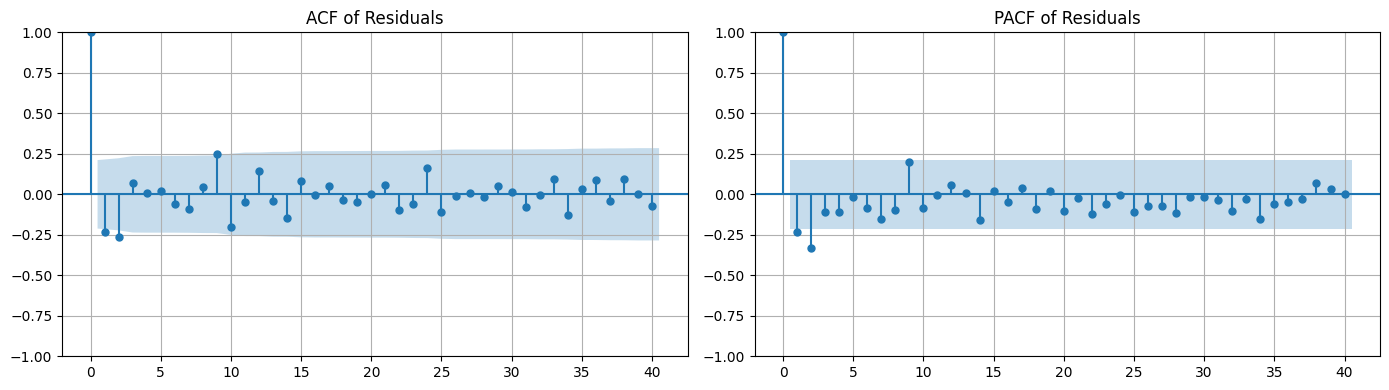

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(residuals, lags=40, ax=ax[0])
ax[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, method='ywm', ax=ax[1])
ax[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

In [ ]:
adf_report(residuals, "ADF on Residuals")

===== ADF on Residuals =====
ADF Statistic : -10.022514
p-value       : 0.000000
Used Lag      : 1
N Observations: 84
Critical Values:
   1%: -3.510712
   5%: -2.896616
   10%: -2.585482
Conclusion    : السلسلة ثابتة ✅


In [ ]:
print("Residual Mean :", residuals.mean())
print("Residual Std  :", residuals.std())

Residual Mean : -34.5760988372093
Residual Std  : 3259.838140185837


## كيف نفسر البواقي؟

إذا وجدنا أن:

- البواقي تتذبذب حول الصفر
- لا يوجد نمط واضح في الرسم
- ACF و PACF للبواقي لا يظهران ارتباطات قوية
- التوزيع قريب من العشوائية

فهذا مؤشر جيد على أن النموذج مناسب نسبيًا.

## إعادة تدريب أفضل نموذج على كامل البيانات

بعد اختيار النموذج الأفضل، نقوم بإعادة تدريبه على **جميع البيانات** حتى يستفيد من أكبر كمية ممكنة من المعلومات قبل حفظه واستخدامه مستقبلًا.

In [ ]:
if best_model_name == "ARMA":
    full_series_diff = series.diff().dropna()
    best_final_model = ARIMA(full_series_diff, order=(best_arma_order[0], 0, best_arma_order[1])).fit()

elif best_model_name == "ARIMA":
    best_final_model = ARIMA(series, order=best_arima_order).fit()

elif best_model_name == "SARIMA":
    best_final_model = SARIMAX(
        series,
        order=best_sarima_cfg[0],
        seasonal_order=best_sarima_cfg[1],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

else:
    best_final_model = None

print("Final model trained successfully.")

Final model trained successfully.


## حفظ أفضل نموذج

سنحفظ النموذج حتى نستخدمه لاحقًا في:

- التنبؤ المستقبلي
- النشر في تطبيق
- إعادة تحميله دون إعادة التدريب

In [ ]:
model_save_path = "/content/drive/MyDrive/best_time_series_model.pkl"

with open(model_save_path, "wb") as f:
    pickle.dump(best_final_model, f)

print("Model saved to:", model_save_path)

Model saved to: /content/drive/MyDrive/best_time_series_model.pkl


## كيفية تحميل النموذج لاحقًا

In [ ]:
with open("/content/drive/MyDrive/best_time_series_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully.")

Model loaded successfully.


## التنبؤ المستقبلي

بعد تحميل النموذج يمكننا استخدامه لإنتاج تنبؤات مستقبلية.

In [ ]:
# مثال: التنبؤ لـ 12 فترة مستقبلية
future_steps = 12

future_fc = loaded_model.get_forecast(steps=future_steps)
future_mean = future_fc.predicted_mean
future_ci = future_fc.conf_int()

print(future_mean)

AttributeError: 'NoneType' object has no attribute 'get_forecast'

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(series.index, series.values, label="Historical Series")
plt.plot(future_mean.index, future_mean.values, label="Future Forecast")
plt.fill_between(future_mean.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], alpha=0.2, label="Confidence Interval")
plt.title("Future Forecast")
plt.legend()
plt.show()

# الخلاصة

في هذا النوت بوك قمنا ببناء مسار متكامل لتحليل ونمذجة سلسلة زمنية:

1. استكشفنا شكل السلسلة الزمنية
2. فحصنا توزيع القيم
3. اختبرنا الثبات باستخدام ADF
4. قمنا بتفكيك السلسلة إلى ترند وموسمية وبواقي
5. عالجنا السلسلة باستخدام التفريق
6. قسمنا البيانات إلى تدريب واختبار
7. بنينا نماذج Baseline و ARMA و ARIMA و SARIMA
8. قارنا النماذج باستخدام RMSE و MAE و AIC
9. حللنا بواقي أفضل نموذج
10. أعدنا تدريب النموذج الأفضل على كامل البيانات
11. حفظنا النموذج لاستخدامه في التنبؤ المستقبلي

# استكمال النوت بوك: نماذج Machine Learning للسلاسل الزمنية

بعد بناء النماذج الإحصائية التقليدية:

- **ARMA**
- **ARIMA**
- **SARIMA**

سننتقل الآن إلى تجربة نماذج **Machine Learning** التي يمكن استخدامها أيضًا في التنبؤ بالسلاسل الزمنية، ثم نقارن أداءها مع النماذج السابقة.

سنجرّب في هذا الجزء نماذج مثل:

- **Linear Regression**
- **Decision Tree Regressor**
- **Random Forest Regressor**
- **Gradient Boosting Regressor**
- **XGBoost** (اختياري إذا كانت المكتبة متاحة)

لكن قبل استخدام هذه النماذج، يجب أن نحول السلسلة الزمنية إلى صيغة مناسبة للتعلّم الآلي، لأن هذه النماذج لا تتعامل مع البعد الزمني تلقائيًا، بل تحتاج إلى **Features** رقمية تمثل الماضي.

سنمر بالمراحل التالية:

1. تحويل السلسلة الزمنية إلى بيانات Supervised
2. إنشاء **Lag Features**
3. إنشاء **Rolling Features**
4. إنشاء **Time Features**
5. تقسيم البيانات إلى تدريب واختبار
6. تدريب نماذج Machine Learning
7. تقييم النماذج باستخدام RMSE و MAE
8. مقارنة النتائج مع النماذج الإحصائية السابقة
9. اختيار أفضل نموذج

## استيراد مكتبات Machine Learning

سنستخدم مجموعة من نماذج الانحدار المناسبة للتنبؤ بالقيم المستمرة، لأن مسألة التنبؤ الزمني هنا هي **Regression Problem**.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

## تحويل السلسلة الزمنية إلى صيغة Supervised Learning

في نماذج السلاسل الزمنية الإحصائية مثل ARIMA، يتم أخذ القيم السابقة زمنيًا بشكل ضمني داخل النموذج.

أما في **Machine Learning**، فعلينا أن نبني هذه العلاقات يدويًا من خلال إنشاء أعمدة تمثل:

- القيم السابقة (**Lag Features**)
- المتوسطات المتحركة (**Rolling Features**)
- معلومات التاريخ مثل الشهر والسنة (**Time Features**)

على سبيل المثال:

- قيمة اليوم السابق
- قيمة آخر شهرين
- متوسط آخر 3 فترات
- رقم الشهر
- رقم السنة

وبذلك يصبح بإمكان النموذج التعلّم من الأنماط الماضية للتنبؤ بالقيمة الحالية.

In [ ]:
def create_ml_features(series, n_lags=12):
    df_ml = pd.DataFrame({"Value": series.copy()})

    # Lag Features
    for lag in range(1, n_lags + 1):
        df_ml[f"lag_{lag}"] = df_ml["Value"].shift(lag)

    # Rolling Features
    df_ml["rolling_mean_3"] = df_ml["Value"].shift(1).rolling(window=3).mean()
    df_ml["rolling_std_3"] = df_ml["Value"].shift(1).rolling(window=3).std()

    df_ml["rolling_mean_6"] = df_ml["Value"].shift(1).rolling(window=6).mean()
    df_ml["rolling_std_6"] = df_ml["Value"].shift(1).rolling(window=6).std()

    # Time Features
    df_ml["month"] = df_ml.index.month
    df_ml["quarter"] = df_ml.index.quarter
    df_ml["year"] = df_ml.index.year

    # حذف القيم المفقودة الناتجة عن الـ shifts والـ rolling
    df_ml = df_ml.dropna()

    return df_ml

ml_data = create_ml_features(series, n_lags=12)

print("Machine Learning dataset shape:", ml_data.shape)
display(ml_data.head())

Machine Learning dataset shape: (272, 20)


,Value,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,month,quarter,year
DATE,,,,,,,,,,,,,,,,,,,,
2003-01-01,29394.2574,27846.6724,26213.8701,26984.1648,25765.5251,26540.5895,27008.8079,25798.9125,27225.6670,26404.6552,27141.8805,24172.4697,28024.1025,27014.902433,816.835014,26726.604967,724.113241,1,1,2003
2003-02-01,29305.2243,29394.2574,27846.6724,26213.8701,26984.1648,25765.5251,26540.5895,27008.8079,25798.9125,27225.6670,26404.6552,27141.8805,24172.4697,27818.266633,1590.383919,27124.179883,1319.851207,2,1,2003
2003-03-01,32415.4981,29305.2243,29394.2574,27846.6724,26213.8701,26984.1648,25765.5251,26540.5895,27008.8079,25798.9125,27225.6670,26404.6552,27141.8805,28848.718033,868.938037,27584.952350,1539.645769,3,1,2003
2003-04-01,39025.0882,32415.4981,29305.2243,29394.2574,27846.6724,26213.8701,26984.1648,25765.5251,26540.5895,27008.8079,25798.9125,27225.6670,26404.6552,30371.659933,1770.575489,28693.281183,2213.867447,4,2,2003
2003-05-01,41124.3601,39025.0882,32415.4981,29305.2243,29394.2574,27846.6724,26213.8701,26984.1648,25765.5251,26540.5895,27008.8079,25798.9125,27225.6670,33581.936867,4963.806312,30700.101750,4564.366989,5,2,2003


## ماذا تعني هذه الخصائص؟

قمنا بإنشاء ثلاثة أنواع من الخصائص:

### 1) Lag Features
تمثل القيم السابقة مباشرة مثل:

- `lag_1` = قيمة الفترة السابقة
- `lag_2` = قيمة فترتين سابقتين
- ...
- `lag_12` = قيمة قبل 12 فترة

إذا كانت البيانات شهرية، فإن `lag_12` يكون مهمًا جدًا لأنه يمثل نفس الشهر من السنة السابقة.

### 2) Rolling Features
تعطي ملخصًا عن السلوك الحديث للسلسلة، مثل:

- متوسط آخر 3 فترات
- انحراف معياري آخر 3 فترات
- متوسط آخر 6 فترات
- انحراف معياري آخر 6 فترات

وهذه الخصائص تساعد النموذج على فهم مستوى السلسلة وتقلباتها.

### 3) Time Features
تشمل:

- `month`
- `quarter`
- `year`

وهذه الخصائص تساعد النماذج على التقاط الأنماط الموسمية والزمنية.

## فصل المتغيرات المستقلة عن الهدف

سنعتبر أن:

- **الهدف** هو العمود `Value`
- **المدخلات** هي باقي الخصائص التي أنشأناها

In [ ]:
X_ml = ml_data.drop(columns=["Value"])
y_ml = ml_data["Value"]

print("X shape:", X_ml.shape)
print("y shape:", y_ml.shape)

X shape: (272, 19)
y shape: (272,)


## تقسيم البيانات إلى تدريب واختبار

في السلاسل الزمنية لا يجوز استخدام تقسيم عشوائي، لأننا نريد أن نحاكي الواقع:

- النموذج يتعلم من الماضي
- ثم يتنبأ بالمستقبل

لذلك سنستخدم **تقسيمًا زمنيًا** بحيث تكون أول 70% للتدريب وآخر 30% للاختبار.

In [ ]:
split_idx_ml = int(len(ml_data) * 0.7)

X_train_ml = X_ml.iloc[:split_idx_ml]
X_test_ml  = X_ml.iloc[split_idx_ml:]

y_train_ml = y_ml.iloc[:split_idx_ml]
y_test_ml  = y_ml.iloc[split_idx_ml:]

print("X_train shape:", X_train_ml.shape)
print("X_test shape :", X_test_ml.shape)
print("y_train shape:", y_train_ml.shape)
print("y_test shape :", y_test_ml.shape)

X_train shape: (190, 19)
X_test shape : (82, 19)
y_train shape: (190,)
y_test shape : (82,)


## ملاحظة مهمة قبل المقارنة

لأن بيانات Machine Learning تبدأ بعد حذف القيم المفقودة الناتجة عن إنشاء الـ Lags، فإننا سنحسب أيضًا **Baseline** على نفس مجموعة الاختبار الخاصة بالـ Machine Learning حتى تكون المقارنة عادلة.

In [ ]:
baseline_ml_pred = X_test_ml["lag_1"].values

baseline_ml_rmse = rmse(y_test_ml.values, baseline_ml_pred)
baseline_ml_mae = mae(y_test_ml.values, baseline_ml_pred)

print("Baseline ML RMSE:", baseline_ml_rmse)
print("Baseline ML MAE :", baseline_ml_mae)

Baseline ML RMSE: 3306.6451853322615
Baseline ML MAE : 1993.9949134146339


## نموذج Linear Regression

يُعد هذا النموذج من أبسط نماذج الانحدار، ويفترض وجود علاقة خطية تقريبية بين الخصائص والمدخلات.

ورغم بساطته، فإنه أحيانًا يعطي نتائج جيدة إذا كانت السلسلة تحمل علاقات منتظمة وواضحة.

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train_ml)

lr_pred = lr_model.predict(X_test_ml)

lr_rmse = rmse(y_test_ml.values, lr_pred)
lr_mae = mae(y_test_ml.values, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE :", lr_mae)

Linear Regression RMSE: 3275.4892651128935
Linear Regression MAE : 1971.0749704442846


## نموذج Decision Tree Regressor

شجرة القرار قادرة على التقاط بعض العلاقات غير الخطية، لكنها قد تكون حساسة للتذبذب وقد تعاني من **Overfitting** إذا لم يتم ضبطها جيدًا.

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_ml, y_train_ml)

dt_pred = dt_model.predict(X_test_ml)

dt_rmse = rmse(y_test_ml.values, dt_pred)
dt_mae = mae(y_test_ml.values, dt_pred)

print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree MAE :", dt_mae)

Decision Tree RMSE: 3486.130084169361
Decision Tree MAE : 2496.4320115607657


## نموذج Random Forest Regressor

الغابة العشوائية عبارة عن مجموعة من أشجار القرار، ويتم دمج نتائجها للحصول على نموذج أكثر استقرارًا وأقل عرضة للمبالغة في التعلّم.

غالبًا ما يكون هذا النموذج أقوى من شجرة القرار المفردة.


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_ml, y_train_ml)

rf_pred = rf_model.predict(X_test_ml)

rf_rmse = rmse(y_test_ml.values, rf_pred)
rf_mae = mae(y_test_ml.values, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE :", rf_mae)

Random Forest RMSE: 2711.020882827463
Random Forest MAE : 1761.1692680604413


## نموذج Gradient Boosting Regressor

هذا النموذج يعتمد على بناء عدد من النماذج الضعيفة بشكل تدريجي، بحيث يحاول كل نموذج جديد تصحيح أخطاء النموذج السابق.

وغالبًا ما يكون قويًا جدًا في مسائل الانحدار.

In [ ]:
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train_ml, y_train_ml)

gbr_pred = gbr_model.predict(X_test_ml)

gbr_rmse = rmse(y_test_ml.values, gbr_pred)
gbr_mae = mae(y_test_ml.values, gbr_pred)

print("Gradient Boosting RMSE:", gbr_rmse)
print("Gradient Boosting MAE :", gbr_mae)

Gradient Boosting RMSE: 2686.975735108635
Gradient Boosting MAE : 1706.0624959050244


## نموذج XGBoost (اختياري)

إذا كانت مكتبة `xgboost` متاحة، فيمكن تجربة هذا النموذج لأنه غالبًا يقدم أداءً ممتازًا في مسائل التنبؤ.

إذا لم تكن المكتبة متوفرة، يمكن تخطي هذا الجزء.

In [ ]:
!pip install xgboost

In [ ]:
xgb_available = True

try:
    from xgboost import XGBRegressor
except:
    xgb_available = False
    print("XGBoost is not installed. Skipping XGBoost model.")

In [ ]:
if xgb_available:
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_train_ml, y_train_ml)

    xgb_pred = xgb_model.predict(X_test_ml)

    xgb_rmse = rmse(y_test_ml.values, xgb_pred)
    xgb_mae = mae(y_test_ml.values, xgb_pred)

    print("XGBoost RMSE:", xgb_rmse)
    print("XGBoost MAE :", xgb_mae)

XGBoost RMSE: 2700.0592316960096
XGBoost MAE : 1640.3852684832318


## مقارنة القيم الحقيقية بالتنبؤات

سنرسم القيم الحقيقية مع تنبؤات كل نموذج حتى نلاحظ:

- مدى قرب النموذج من السلسلة الحقيقية
- هل النموذج يلتقط القمم والهبوطات؟
- هل التنبؤات ناعمة أكثر من اللازم؟

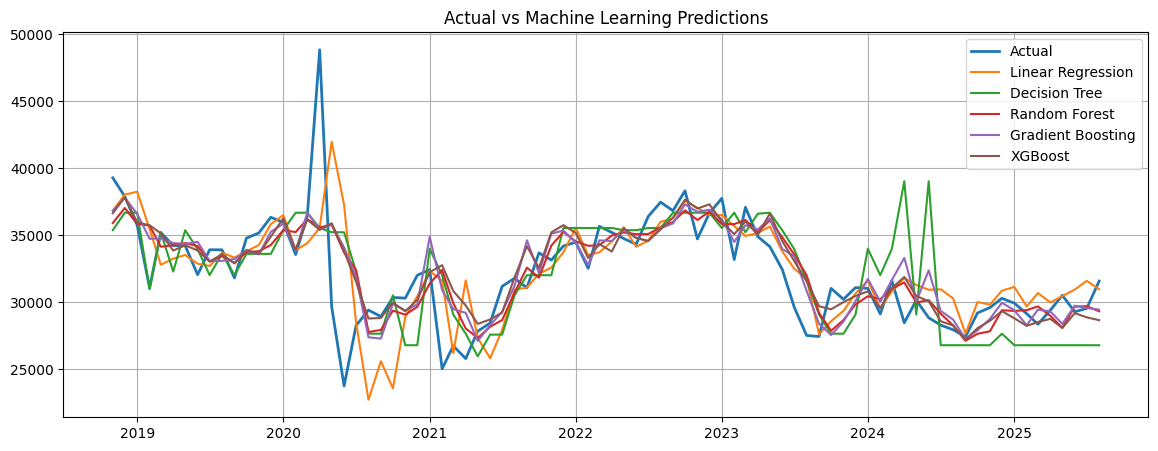

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_ml.index, y_test_ml.values, label="Actual", linewidth=2)
plt.plot(y_test_ml.index, lr_pred, label="Linear Regression")
plt.plot(y_test_ml.index, dt_pred, label="Decision Tree")
plt.plot(y_test_ml.index, rf_pred, label="Random Forest")
plt.plot(y_test_ml.index, gbr_pred, label="Gradient Boosting")

if xgb_available:
    plt.plot(y_test_ml.index, xgb_pred, label="XGBoost")

plt.title("Actual vs Machine Learning Predictions")
plt.legend()
plt.show()

## مقارنة نماذج Machine Learning

سنقارن النماذج بناءً على:

- **RMSE**
- **MAE**

وكلما انخفضت هذه القيم كان أداء النموذج أفضل.

In [ ]:
ml_results = [
    ["Baseline_ML", baseline_ml_rmse, baseline_ml_mae],
    ["Linear Regression", lr_rmse, lr_mae],
    ["Decision Tree", dt_rmse, dt_mae],
    ["Random Forest", rf_rmse, rf_mae],
    ["Gradient Boosting", gbr_rmse, gbr_mae]
]

if xgb_available:
    ml_results.append(["XGBoost", xgb_rmse, xgb_mae])

ml_results_df = pd.DataFrame(ml_results, columns=["Model", "RMSE", "MAE"])
ml_results_df = ml_results_df.sort_values("RMSE", ascending=True)

display(ml_results_df)

,Model,RMSE,MAE
4,Gradient Boosting,2686.975735,1706.062496
5,XGBoost,2700.059232,1640.385268
3,Random Forest,2711.020883,1761.169268
1,Linear Regression,3275.489265,1971.074970
0,Baseline_ML,3306.645185,1993.994913
2,Decision Tree,3486.130084,2496.432012


## المقارنة النهائية بين النماذج الإحصائية ونماذج Machine Learning

الآن سنجمع نتائج:

- النماذج الإحصائية
- ونماذج Machine Learning

داخل جدول واحد حتى نعرف أي نموذج كان الأفضل.

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "ARMA",
        "ARIMA",
        "SARIMA",
        "Baseline_ML",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        baseline_rmse,
        arma_rmse,
        arima_rmse,
        sarima_rmse,
        baseline_ml_rmse,
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gbr_rmse
    ],
    "MAE": [
        baseline_mae,
        arma_mae,
        arima_mae,
        sarima_mae,
        baseline_ml_mae,
        lr_mae,
        dt_mae,
        rf_mae,
        gbr_mae
    ],
    "Type": [
        "Statistical",
        "Statistical",
        "Statistical",
        "Statistical",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning",
        "Machine Learning"
    ]
})

if xgb_available:
    final_comparison.loc[len(final_comparison)] = [
        "XGBoost",
        xgb_rmse,
        xgb_mae,
        "Machine Learning"
    ]

final_comparison = final_comparison.sort_values("RMSE", ascending=True)
display(final_comparison)

NameError: name 'baseline_rmse' is not defined

In [ ]:
plt.figure(figsize=(12, 6))
plt.barh(final_comparison["Model"], final_comparison["RMSE"])
plt.title("Final Comparison of Statistical vs Machine Learning Models")
plt.xlabel("RMSE")
plt.gca().invert_yaxis()
plt.show()

NameError: name 'final_comparison' is not defined

<Figure size 1200x600 with 0 Axes>

## اختيار أفضل نموذج

سنختار النموذج الأفضل بناءً على أقل قيمة **RMSE**، مع مراعاة:

- هل الأداء أفضل فعلًا؟
- هل النموذج مستقر؟
- هل تفسيره سهل؟
- هل يصلح للاستخدام لاحقًا في التطبيق؟

In [ ]:
best_overall_model_name = final_comparison.iloc[0]["Model"]
print("Best overall model based on RMSE:", best_overall_model_name)

NameError: name 'final_comparison' is not defined

## حفظ أفضل نموذج من نماذج Machine Learning

إذا كان أفضل نموذج من نوع Machine Learning، فيمكن حفظه باستخدام `pickle` لاستخدامه لاحقًا في تطبيق مثل Streamlit.

In [ ]:
best_ml_model = None

if best_overall_model_name == "Linear Regression":
    best_ml_model = lr_model
elif best_overall_model_name == "Decision Tree":
    best_ml_model = dt_model
elif best_overall_model_name == "Random Forest":
    best_ml_model = rf_model
elif best_overall_model_name == "Gradient Boosting":
    best_ml_model = gbr_model
elif xgb_available and best_overall_model_name == "XGBoost":
    best_ml_model = xgb_model

if best_ml_model is not None:
    ml_model_save_path = "/content/drive/MyDrive/best_ml_time_series_model.pkl"

    with open(ml_model_save_path, "wb") as f:
        pickle.dump(best_ml_model, f)

    print("Best ML model saved to:", ml_model_save_path)
else:
    print("Best overall model is not a Machine Learning model.")

# الخلاصة النهائية بعد إضافة Machine Learning

في هذا الجزء قمنا بتوسيع مشروع السلاسل الزمنية بإضافة نماذج **Machine Learning** إلى جانب النماذج الإحصائية التقليدية.

وقد قمنا بما يلي:

1. تحويل السلسلة الزمنية إلى صيغة **Supervised Learning**
2. إنشاء **Lag Features** لتمثيل الماضي
3. إنشاء **Rolling Features** لالتقاط المتوسطات والتقلبات
4. إنشاء **Time Features** مثل الشهر والربع والسنة
5. تدريب عدة نماذج Machine Learning
6. تقييم النماذج باستخدام **RMSE** و **MAE**
7. مقارنة النتائج مع **ARMA / ARIMA / SARIMA**
8. اختيار أفضل نموذج بناءً على الأداء

### ملاحظات مهمة:
- إذا تفوقت النماذج الإحصائية مثل **SARIMA** فهذا يعني أن السلسلة تعتمد بشكل كبير على **الموسمية والاعتماد الزمني التقليدي**
- إذا تفوقت نماذج **Machine Learning** فهذا قد يدل على وجود **علاقات غير خطية** أو أن الخصائص التي أنشأناها ساعدت النموذج على فهم السلسلة بشكل أفضل
- لا يوجد نموذج أفضل دائمًا، بل يعتمد ذلك على طبيعة البيانات نفسها

وبالتالي فإن المقارنة بين النماذج الإحصائية ونماذج التعلم الآلي تعتبر خطوة أساسية جدًا قبل اختيار النموذج النهائي للنشر أو الاستخدام في تطبيق عملي.

# استكمال النوت بوك: نماذج Deep Learning للسلاسل الزمنية

بعد تجربة:

- النماذج الإحصائية مثل **ARMA / ARIMA / SARIMA**
- ونماذج **Machine Learning**

سننتقل الآن إلى نماذج **Deep Learning** التي تُستخدم كثيرًا في السلاسل الزمنية، خصوصًا عندما تكون العلاقات داخل البيانات:

- غير خطية
- طويلة المدى
- معقدة
- تحتوي على أنماط يصعب على النماذج التقليدية التقاطها

في هذا الجزء سنجرّب:

- **Simple RNN**
- **LSTM**
- **GRU**

وسنمر بالمراحل التالية:

1. تجهيز البيانات لتناسب الشبكات العصبية
2. تطبيع البيانات
3. تحويل السلسلة إلى تسلسلات زمنية
4. بناء نماذج Deep Learning
5. تدريب النماذج
6. تقييم الأداء باستخدام RMSE و MAE
7. مقارنة النتائج مع النماذج السابقة
8. اختيار أفضل نموذج

## استيراد مكتبات Deep Learning

سنستخدم مكتبة **TensorFlow / Keras** لبناء نماذج الشبكات العصبية الخاصة بالسلاسل الزمنية.

In [ ]:
!pip install tensorflow

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

## لماذا نحتاج تجهيزًا مختلفًا للـ Deep Learning؟

نماذج Deep Learning لا تستقبل السلسلة الزمنية كعمود واحد فقط، بل تحتاج إلى إدخال البيانات على شكل:

- **عينات Samples**
- **خطوات زمنية Timesteps**
- **خصائص Features**

أي أن الشكل المطلوب عادة يكون:

`[عدد العينات, عدد الخطوات الزمنية, عدد الخصائص]`

ولهذا سنحوّل السلسلة إلى نوافذ زمنية، بحيث:

- آخر 12 قيمة ← تُستخدم للتنبؤ بالقيمة التالية

إذا كانت البيانات شهرية، فاختيار 12 خطوة زمنية يعتبر منطقيًا لأنه يمثل سنة كاملة.

## تطبيع البيانات

الشبكات العصبية تعمل عادة بشكل أفضل عندما تكون القيم في مدى صغير ومنظم.

لذلك سنستخدم **MinMaxScaler** لتحويل القيم إلى مدى بين 0 و 1.

In [ ]:
series_values = series.values.reshape(-1, 1)

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series_values)

print("Original shape:", series_values.shape)
print("Scaled shape  :", series_scaled.shape)

Original shape: (284, 1)
Scaled shape  : (284, 1)


## تحويل السلسلة إلى Sequences

سنقوم بإنشاء نوافذ زمنية ثابتة الطول.

على سبيل المثال إذا اخترنا:

- `sequence_length = 12`

فهذا يعني:

- أول 12 قيمة ← مدخلات
- القيمة رقم 13 ← الهدف

ثم:
- القيم من 2 إلى 13 ← مدخلات
- القيمة رقم 14 ← الهدف

وهكذا.

In [ ]:
def create_sequences(data, sequence_length=12):
    X, y = [], []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y

sequence_length = 12

X_dl, y_dl = create_sequences(series_scaled, sequence_length=sequence_length)

print("X_dl shape before reshape:", X_dl.shape)
print("y_dl shape:", y_dl.shape)

X_dl shape before reshape: (272, 12)
y_dl shape: (272,)


## إعادة تشكيل X لتناسب الشبكات العصبية

حاليًا شكل `X` هو:

- `[samples, timesteps]`

لكن نماذج RNN/LSTM/GRU تحتاج:

- `[samples, timesteps, features]`

وبما أننا نستخدم سلسلة أحادية المتغير، فعدد الخصائص = 1.

In [ ]:
X_dl = X_dl.reshape((X_dl.shape[0], X_dl.shape[1], 1))

print("X_dl shape after reshape:", X_dl.shape)

X_dl shape after reshape: (272, 12, 1)


## تقسيم البيانات إلى تدريب واختبار

كما في السلاسل الزمنية، سنستخدم تقسيمًا زمنيًا وليس عشوائيًا:

- أول 70% للتدريب
- آخر 30% للاختبار

In [ ]:
split_idx_dl = int(len(X_dl) * 0.7)

X_train_dl = X_dl[:split_idx_dl]
X_test_dl  = X_dl[split_idx_dl:]

y_train_dl = y_dl[:split_idx_dl]
y_test_dl  = y_dl[split_idx_dl:]

print("X_train_dl:", X_train_dl.shape)
print("X_test_dl :", X_test_dl.shape)
print("y_train_dl:", y_train_dl.shape)
print("y_test_dl :", y_test_dl.shape)

X_train_dl: (190, 12, 1)
X_test_dl : (82, 12, 1)
y_train_dl: (190,)
y_test_dl : (82,)


## استخدام Early Stopping

بما أن نماذج Deep Learning قد تتعرض لـ **Overfitting**، فسنستخدم **EarlyStopping** لإيقاف التدريب عندما لا يتحسن أداء التحقق.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## نموذج Simple RNN

هذا النموذج هو أبسط نوع من الشبكات المتكررة، ويأخذ التسلسل الزمني كمدخل.

لكن غالبًا يعاني من ضعف في التقاط العلاقات الطويلة المدى مقارنة بـ LSTM و GRU.

In [ ]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

rnn_history = rnn_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0422 - val_loss: 0.0163
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0225 - val_loss: 0.0047
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0126 - val_loss: 0.0031
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0106 - val_loss: 0.0022
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0139 - val_loss: 0.0019
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0110 - val_loss: 0.0018
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0103 - val_loss: 0.0021
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0085 - val_loss: 0.0022
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0098 - val_loss: 0.0018
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0104 - val_loss: 0.0016
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0090 - val_loss: 0.0019
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

In [ ]:
rnn_pred_scaled = rnn_model.predict(X_test_dl)

rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_dl.reshape(-1, 1))

rnn_rmse = rmse(y_test_actual.flatten(), rnn_pred.flatten())
rnn_mae = mae(y_test_actual.flatten(), rnn_pred.flatten())

print("Simple RNN RMSE:", rnn_rmse)
print("Simple RNN MAE :", rnn_mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step
Simple RNN RMSE: 3159.4042986719382
Simple RNN MAE : 1895.0888320503045


## نموذج LSTM

يُعد **LSTM** من أشهر النماذج في السلاسل الزمنية، لأنه مصمم للتعامل مع الاعتماديات طويلة المدى داخل التسلسل.

وهو غالبًا أفضل من Simple RNN في التقاط العلاقات الزمنية المعقدة.

In [ ]:
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_history = lstm_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0828 - val_loss: 0.0108
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0228 - val_loss: 0.0058
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0138 - val_loss: 0.0064
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0126 - val_loss: 0.0069
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0137 - val_loss: 0.0056
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0115 - val_loss: 0.0051
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0121 - val_loss: 0.0054
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0119 - val_loss: 0.0050
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0109 - val_loss: 0.0052
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0108 - val_loss: 0.0050


In [ ]:
lstm_pred_scaled = lstm_model.predict(X_test_dl)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

lstm_rmse = rmse(y_test_actual.flatten(), lstm_pred.flatten())
lstm_mae = mae(y_test_actual.flatten(), lstm_pred.flatten())

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE :", lstm_mae)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step
LSTM RMSE: 4095.398190852867
LSTM MAE : 3131.120123246951


## نموذج GRU

يشبه **GRU** نموذج LSTM، لكنه أبسط من ناحية البنية الداخلية وأقل في عدد المعاملات.

في كثير من الحالات يعطي أداء قريبًا جدًا من LSTM، وأحيانًا يتفوق عليه مع سرعة تدريب أفضل.

In [ ]:
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(sequence_length, 1)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_history = gru_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - loss: 0.0626 - val_loss: 0.0037
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0184 - val_loss: 0.0043
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0100 - val_loss: 0.0053
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0103 - val_loss: 0.0029
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0094 - val_loss: 0.0029
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0091 - val_loss: 0.0028
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0096 - val_loss: 0.0028
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0085 - val_loss: 0.0028
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0082 - val_loss: 0.0029
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0088 - val_loss: 0.0028


In [ ]:
gru_pred_scaled = gru_model.predict(X_test_dl)

gru_pred = scaler.inverse_transform(gru_pred_scaled)

gru_rmse = rmse(y_test_actual.flatten(), gru_pred.flatten())
gru_mae = mae(y_test_actual.flatten(), gru_pred.flatten())

print("GRU RMSE:", gru_rmse)
print("GRU MAE :", gru_mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
GRU RMSE: 3476.9273528438393
GRU MAE : 2477.247879573171


## منحنيات التدريب

سنرسم خسارة التدريب وخسارة التحقق حتى نرى:

- هل النموذج يتعلم بشكل جيد؟
- هل يوجد Overfitting؟
- هل التوقف المبكر كان مناسبًا؟

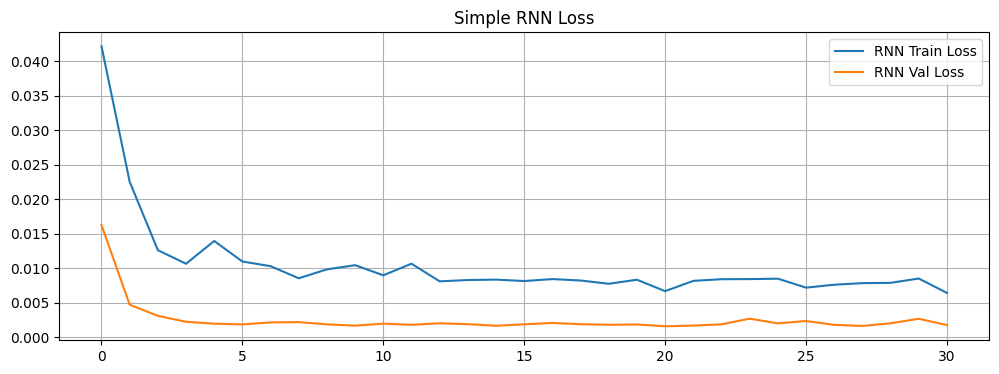

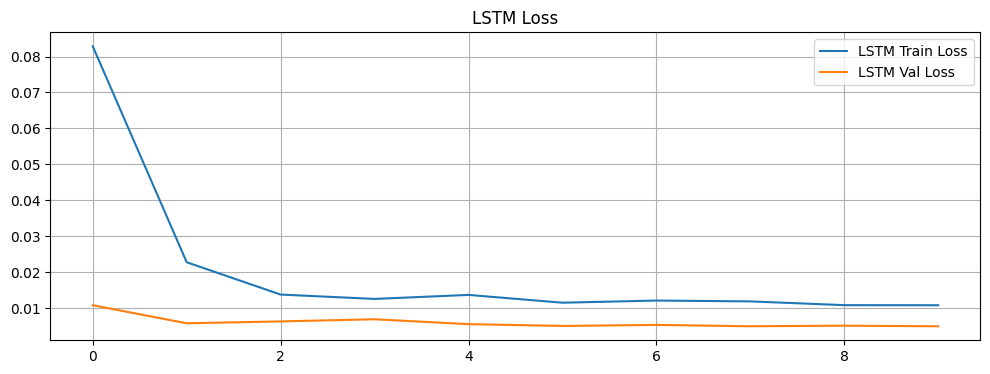

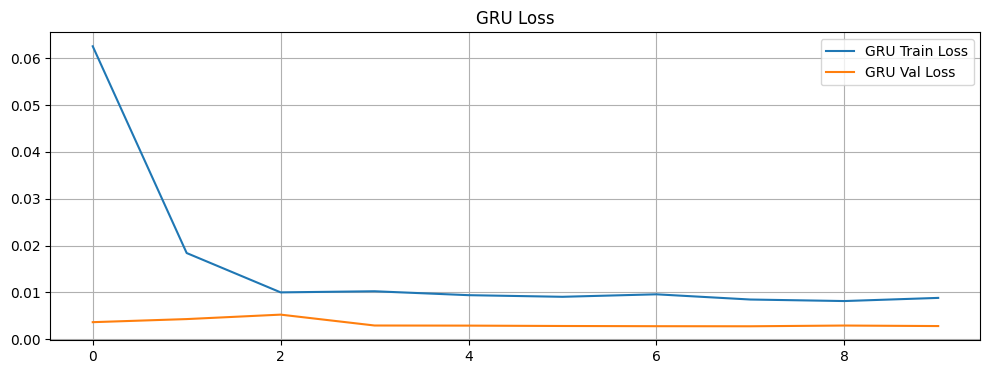

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
plt.title("Simple RNN Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
plt.title("LSTM Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(gru_history.history['loss'], label='GRU Train Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Val Loss')
plt.title("GRU Loss")
plt.legend()
plt.show()

## مقارنة القيم الحقيقية مع تنبؤات نماذج Deep Learning

هذا الرسم يساعدنا على رؤية مدى قرب كل نموذج من القيم الحقيقية، وهل يلتقط الاتجاه والموسمية والتغيرات بشكل جيد.

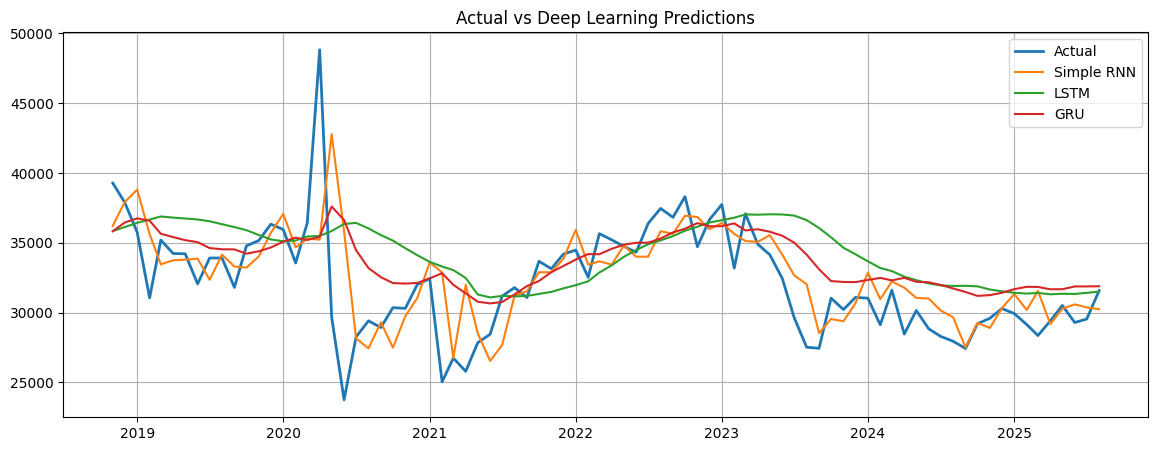

In [ ]:
test_index_dl = series.index[sequence_length:][split_idx_dl:]

plt.figure(figsize=(14, 5))
plt.plot(test_index_dl, y_test_actual.flatten(), label="Actual", linewidth=2)
plt.plot(test_index_dl, rnn_pred.flatten(), label="Simple RNN")
plt.plot(test_index_dl, lstm_pred.flatten(), label="LSTM")
plt.plot(test_index_dl, gru_pred.flatten(), label="GRU")
plt.title("Actual vs Deep Learning Predictions")
plt.legend()
plt.show()

## مقارنة نماذج Deep Learning

سنقارن بين النماذج الثلاثة باستخدام:

- **RMSE**
- **MAE**

وكلما انخفضت القيم كان الأداء أفضل.

In [ ]:
dl_results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae]
})

dl_results = dl_results.sort_values("RMSE", ascending=True)
display(dl_results)

,Model,RMSE,MAE
0,Simple RNN,3159.404299,1895.088832
2,GRU,3476.927353,2477.247880
1,LSTM,4095.398191,3131.120123


## المقارنة النهائية بين جميع النماذج

الآن سنضيف نتائج Deep Learning إلى النتائج السابقة، حتى نقارن بين:

- النماذج الإحصائية
- نماذج Machine Learning
- نماذج Deep Learning

In [ ]:
# deep_models_df = pd.DataFrame({
#     "Model": ["Simple RNN", "LSTM", "GRU"],
#     "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
#     "MAE": [rnn_mae, lstm_mae, gru_mae],
#     "Type": ["Deep Learning", "Deep Learning", "Deep Learning"]
# })

# all_models_comparison = pd.concat([final_comparison, deep_models_df], ignore_index=True)
# all_models_comparison = all_models_comparison.sort_values("RMSE", ascending=True)

# display(all_models_comparison)

NameError: name 'final_comparison' is not defined

In [ ]:
# plt.figure(figsize=(12, 7))
# plt.barh(all_models_comparison["Model"], all_models_comparison["RMSE"])
# plt.title("Comparison of Statistical, ML, and Deep Learning Models")
# plt.xlabel("RMSE")
# plt.gca().invert_yaxis()
# plt.show()

## اختيار أفضل نموذج نهائي

سنختار النموذج الأفضل بناءً على أقل قيمة **RMSE**، ثم نحدد هل هو:

- نموذج إحصائي
- Machine Learning
- Deep Learning

In [ ]:
best_model_overall = all_models_comparison.iloc[0]["Model"]
print("Best overall model:", best_model_overall)

## حفظ أفضل نموذج Deep Learning

إذا كان أفضل نموذج من نوع Deep Learning، يمكننا حفظه بصيغة `.keras` أو `.h5` لاستخدامه لاحقًا في التطبيق.

In [ ]:
if best_model_overall == "Simple RNN":
    best_dl_model = rnn_model
elif best_model_overall == "LSTM":
    best_dl_model = lstm_model
elif best_model_overall == "GRU":
    best_dl_model = gru_model
else:
    best_dl_model = None

if best_dl_model is not None:
    best_dl_model.save("/content/drive/MyDrive/best_deep_learning_time_series_model.keras")
    print("Best deep learning model saved successfully.")
else:
    print("Best model is not a deep learning model.")

## التنبؤ المستقبلي باستخدام نموذج Deep Learning

إذا أردنا التنبؤ بعدة فترات مستقبلية، فيجب أن نستخدم آخر نافذة زمنية متاحة، ثم:

1. نتنبأ بالقيمة التالية
2. نضيفها إلى النافذة
3. نحذف أقدم قيمة
4. نكرر العملية حتى نصل إلى عدد الخطوات المطلوبة

In [ ]:
def forecast_future_dl(model, last_sequence, future_steps, scaler):
    future_predictions = []
    current_seq = last_sequence.copy()

    for _ in range(future_steps):
        pred_scaled = model.predict(current_seq, verbose=0)[0, 0]
        future_predictions.append(pred_scaled)

        pred_reshaped = np.array([[[pred_scaled]]])
        current_seq = np.concatenate([current_seq[:, 1:, :], pred_reshaped], axis=1)

    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions = scaler.inverse_transform(future_predictions)

    return future_predictions

In [ ]:
if best_dl_model is not None:
    future_steps = 12

    last_sequence = X_dl[-1:].copy()
    future_preds_dl = forecast_future_dl(best_dl_model, last_sequence, future_steps, scaler)

    future_index = pd.date_range(
        start=series.index[-1] + pd.offsets.MonthBegin(1),
        periods=future_steps,
        freq='MS'
    )

    future_preds_dl_series = pd.Series(future_preds_dl.flatten(), index=future_index)

    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values, label="Historical Series")
    plt.plot(future_preds_dl_series.index, future_preds_dl_series.values, label="Future Forecast (DL)")
    plt.title("Future Forecast using Deep Learning Model")
    plt.legend()
    plt.show()

# الخلاصة النهائية بعد إضافة Deep Learning

في هذا الجزء قمنا بتوسيع مشروع السلاسل الزمنية بإضافة نماذج **Deep Learning** المناسبة للتنبؤ الزمني، وهي:

- **Simple RNN**
- **LSTM**
- **GRU**

وقد قمنا بما يلي:

1. طبعنا البيانات باستخدام **MinMaxScaler**
2. حوّلنا السلسلة إلى تسلسلات زمنية ثابتة الطول
3. جهّزنا البيانات بالشكل المناسب للشبكات العصبية
4. درّبنا عدة نماذج Deep Learning
5. قيّمنا الأداء باستخدام **RMSE** و **MAE**
6. قارنا النتائج مع النماذج الإحصائية ونماذج Machine Learning
7. اخترنا أفضل نموذج بناءً على الأداء
8. حفظنا النموذج الأفضل إذا كان من نوع Deep Learning
9. استخدمناه في التنبؤ المستقبلي

### ملاحظات مهمة:
- **Simple RNN** مناسب كبداية تعليمية، لكنه غالبًا أضعف من LSTM وGRU
- **LSTM** قوي جدًا في التقاط الاعتماديات الزمنية الطويلة
- **GRU** أبسط وأسرع، وغالبًا يعطي نتائج قريبة جدًا من LSTM
- نجاح نماذج Deep Learning يعتمد على:
  - كمية البيانات
  - جودة التسلسلات المختارة
  - طول النافذة الزمنية
  - ضبط المعاملات
- إذا كانت البيانات قليلة جدًا، فقد لا تتفوق نماذج Deep Learning على ARIMA أو SARIMA

وبالتالي فإن تجربة نماذج Deep Learning تعتبر خطوة مهمة جدًا عند بناء مشروع متكامل للسلاسل الزمنية، خاصة إذا كان الهدف النهائي هو الوصول إلى أفضل نموذج ممكن للنشر في تطبيق عملي.